In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import mlxtend
from mlxtend.frequent_patterns import fpgrowth, association_rules, apriori
from mlxtend.preprocessing import TransactionEncoder
import warnings
import IPython
from IPython.display import display, Markdown
import sys
import gc

version_info = f"""
### Environment Setup
- **Python:** `{sys.version.split()[0]}`
- **Pandas:** `{pd.__version__}`
- **NumPy:** `{np.__version__}`
- **Matplotlib:** `{matplotlib.__version__}`
- **Seaborn:** `{sns.__version__}`
- **NetworkX:** `{nx.__version__}`
- **Mlxtend:** `{mlxtend.__version__}`
- **IPython:** `{IPython.__version__}`
"""
display(Markdown(version_info))

# --- Setup & Optimization ---
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='mlxtend')
plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

def optimize_types(df):
    for col in df.columns:
        if df[col].dtype == 'int64': df[col] = df[col].astype('int32')
        elif df[col].dtype == 'float64': df[col] = df[col].astype('float32')
    return df

# --- Data Loading & Preprocessing ---
def load_and_prep_data(sample_orders=1e4):
    products = pd.read_csv('products.csv')
    aisles = pd.read_csv('aisles.csv')
    departments = pd.read_csv('departments.csv')
    orders = pd.read_csv('orders.csv')[['order_id', 'order_dow', 'order_hour_of_day']]
    all_order_ids = pd.read_csv('order_products__prior.csv', usecols=['order_id'])['order_id'].unique()
    
    np.random.seed(42)
    sampled_ids = np.random.choice(all_order_ids, size=int(sample_orders), replace=False)
    order_products = pd.read_csv('order_products__prior.csv')
    order_products = order_products[order_products['order_id'].isin(sampled_ids)]
    
    df = order_products.merge(products, on='product_id', how='left')
    df = df.merge(aisles, on='aisle_id', how='left')
    df = df.merge(departments, on='department_id', how='left')
    df = df.merge(orders, on='order_id', how='left')

    # Dimensional Engineering
    bins = [0, 6, 12, 18, 24]
    labels = ['Night', 'Morning', 'Afternoon', 'Evening']
    df['hour_bin'] = 'Hour_' + pd.cut(df['order_hour_of_day'], bins=bins, labels=labels, right=False).astype(str)
    df['day_type'] = df['order_dow'].apply(lambda x: 'Weekend' if x in [0, 1] else 'Weekday')
    
    basket_counts = df.groupby('order_id')['product_id'].transform('count')
    df['basket_size'] = pd.cut(basket_counts, bins=[0, 5, 15, 100], labels=['Small_Basket', 'Medium_Basket', 'Large_Basket'])
    
    return optimize_types(df)

# --- Exploratory Data Analysis ---
def run_eda(df):
    display(Markdown("## Exploratory Data Analysis"))
    
    # 1. Missing Values Check
    display(Markdown("--- Missing Values Check ---"))
    missing_data = df[['product_name', 'aisle', 'department', 'order_hour_of_day', 'order_dow']].isna().sum()
    display(missing_data.to_frame(name='Missing Count'))
    display(Markdown(f"- **Total transactions (orders):** `{df['order_id'].nunique():,}`\n- **Total unique products:** `{df['product_name'].nunique():,}`"))
    plt.figure(figsize=(16, 10))
    
    # Orders by Day of Week
    plt.subplot(2, 2, 1)
    sns.countplot(data=df.drop_duplicates('order_id'), x='order_dow')
    plt.title('Distribution of Orders by Day of Week')
    plt.xlabel('Day of Week (0=Saturday)')
    plt.ylabel('Number of Orders')
    
    # Orders by Hour of Day
    plt.subplot(2, 2, 2)
    sns.countplot(data=df.drop_duplicates('order_id'), x='order_hour_of_day')
    plt.title('Distribution of Orders by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Orders')
    
    # Top 10 Departments
    plt.subplot(2, 2, 3)
    top_depts = df['department'].value_counts().head(10)
    sns.barplot(y=top_depts.index, x=top_depts.values)
    plt.title('Top 10 Most Frequent Departments')
    plt.xlabel('Frequency')
    plt.ylabel('Department')
    
    # Top 10 Aisles
    plt.subplot(2, 2, 4)
    top_aisles = df['aisle'].value_counts().head(10)
    sns.barplot(y=top_aisles.index, x=top_aisles.values)
    plt.title('Top 10 Most Frequent Aisles')
    plt.xlabel('Frequency')
    plt.ylabel('Aisle')
    
    plt.tight_layout()
    plt.show()
    
    reorder_rate = df.groupby('product_name')['reordered'].mean().sort_values(ascending=False)
    display(Markdown("### Top 10 Products by Reorder Loyalty"))
    display(reorder_rate.head(10))


# --- Core Mining Utilities ---
def get_basket(df, level_column):
    df = df.dropna(subset=[level_column, 'hour_bin', 'day_type', 'basket_size'])
    
    #ounts = df[level_column].value_counts()
    #keep_list = counts[counts > 100].index
    #df = df[df[level_column].isin(keep_list)]
    
    baskets = df.groupby('order_id')[level_column].unique().reset_index()
    meta = df.drop_duplicates('order_id')[['order_id', 'hour_bin', 'day_type', 'basket_size']]
    merged = baskets.merge(meta, on='order_id')
    
    transaction_list = [list(items) + list(meta) for items, meta in zip(merged[level_column], merged[['hour_bin', 'day_type', 'basket_size']].values)]
    
    te = TransactionEncoder()
    te_ary = te.fit(transaction_list).transform(transaction_list, sparse=True)
    return pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

def enhance_rules(rules_df, level_type):
    if rules_df.empty: return rules_df
    
    rules_df['kulczynski'] = (rules_df['support']/rules_df['antecedent support'] + 
                              rules_df['support']/rules_df['consequent support']) / 2
    
    rules_df['ir'] = np.abs(rules_df['antecedent support'] - rules_df['consequent support']) / \
                     (rules_df['antecedent support'] + rules_df['consequent support'] - rules_df['support'])
    
    rules_df['cosine'] = rules_df['support'] / np.sqrt(rules_df['antecedent support'] * rules_df['consequent support'])
    
    if level_type == 'product_name':
        rules_df['is_robust'] = (rules_df['kulczynski'] > 0.3) & (rules_df['ir'] < 0.7)
    else: 
        rules_df['is_robust'] = (rules_df['kulczynski'] > 0.5) & (rules_df['ir'] < 0.5)
    
    rules_df['ant_str'] = rules_df['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_df['cons_str'] = rules_df['consequents'].apply(lambda x: ', '.join(list(x)))
    return rules_df

def filter_redundancy(low_rules, high_rules, mapping):
    if low_rules.empty or high_rules is None or high_rules.empty or mapping is None: return low_rules
    
    high_set = set((tuple(sorted(list(a))), tuple(sorted(list(c)))) for a, c in zip(high_rules['antecedents'], high_rules['consequents']))

    def check_redundancy(row):
        ant_high = tuple(sorted(set(mapping.get(item, item) for item in row['antecedents'])))
        cons_high = tuple(sorted(set(mapping.get(item, item) for item in row['consequents'])))
        return (ant_high, cons_high) in high_set

    return low_rules[~low_rules.apply(check_redundancy, axis=1)]

# --- Visualization ---

def get_top_robust(dim, level, results, n=5):
    key = (dim, level)
    if key in results:
        df = results[key]
        if df.empty: return pd.DataFrame()
        robust_df = df[df['is_robust']].sort_values('lift', ascending=False).head(n).copy()
        if robust_df.empty:
            display(Markdown(f"    No strictly 'robust' rules found for **{dim} -> {level}**. Falling back to top Lift.*"))
            robust_df = df.sort_values('lift', ascending=False).head(n).copy()
        robust_df['Dimension'] = dim
        robust_df[['lift', 'kulczynski', 'cosine']] = robust_df[['lift', 'kulczynski', 'cosine']].round(3)
        return robust_df[['Dimension', 'ant_str', 'cons_str', 'lift', 'kulczynski', 'cosine']]
    return pd.DataFrame()

def plot_robustness(rules_df, title):
    if rules_df.empty: return
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=rules_df, x='kulczynski', y='ir', size='lift', hue='is_robust', palette={True: 'green', False: 'red'}, alpha=0.6)
    plt.title(f"Robustness: {title}")
    plt.axvline(0.5, color='gray', linestyle='--')
    plt.show()

def plot_rules_network(rules_df, title="Association Rules Network", num_rules=50):
    if rules_df.empty: return
    G = nx.DiGraph()
    top_rules = rules_df[rules_df['is_robust']].sort_values('lift', ascending=False).head(num_rules)
    
    for _, row in top_rules.iterrows(): G.add_edge(row['ant_str'], row['cons_str'], weight=row['lift'])

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=1.1, seed=42)
    
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="#ecf0f1", edgecolors='#2C3E50', linewidths=2)
    nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif', font_weight='bold')
    
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    normalized_weights = [(w / max_w) * 5 for w in weights]
    
    nx.draw_networkx_edges(G, pos, width=normalized_weights, edge_color='#3498DB', alpha=0.6, arrowsize=20, connectionstyle='arc3,rad=0.1')

    plt.title(f"{title}\n(Line thickness = Lift)", fontsize=14)
    plt.axis('off')
    plt.show()   
    
def plot_dimensional_heatmap(rules_df, title="Dimensional Heatmap"):
    if rules_df.empty or len(rules_df) < 2: return
    heatmap_data = rules_df.pivot_table(index='ant_str', columns='cons_str', values='lift', aggfunc='max')
    
    if heatmap_data.shape[0] > 15: heatmap_data = heatmap_data.head(15)
    if heatmap_data.shape[1] > 15: heatmap_data = heatmap_data.iloc[:, :15]
        
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Lift'})
    plt.title(f"Rule Lift Heatmap: {title}")
    plt.ylabel("Antecedents")
    plt.xlabel("Consequents")
    plt.tight_layout()
    plt.show()

def plot_algorithm_comparison(performance_log):
    if not performance_log: return
    perf_df = pd.DataFrame(performance_log)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=perf_df.melt(id_vars=['Level', 'Dimension'], value_vars=['Apriori', 'FP-Growth'], 
                                  var_name='Algorithm', value_name='Time (s)'), 
                x='Level', y='Time (s)', hue='Algorithm')
    plt.title('Scalability Comparison: Apriori vs. FP-Growth')
    plt.yscale('log')
    plt.ylabel('Execution Time in Seconds (Log Scale)')
    plt.xlabel('Hierarchy Level')
    plt.show()

# --- Master Pipeline ---
def run_master_analysis(df):
    run_eda(df)
    mapping_data = df[['product_name', 'aisle', 'department']].drop_duplicates()
    prod_to_aisle = mapping_data.set_index('product_name')['aisle'].to_dict()
    aisle_to_dept = mapping_data[['aisle', 'department']].drop_duplicates().set_index('aisle')['department'].to_dict()

    level_configs = [
        ('department', 0.05, None),
        ('aisle', 0.01, aisle_to_dept),
        ('product_name', 0.002, prod_to_aisle)
    ]
    
    results = {}
    performance_log = []

    dimensions = ['Weekend', 'Weekday', 'Hour_Morning', 'Hour_Afternoon', 'Hour_Evening', 'Hour_Night']

    for dim in dimensions:
        display(Markdown(f"<br>\n\n---\n## DIMENSION: **{dim.upper()}**\n---"))
        
        if dim.startswith('Hour_'): df_subset = df[df['hour_bin'] == dim]
        else: df_subset = df[df['day_type'] == dim]
        prev_rules = None
        
        for level, sup, mapping in level_configs:
            basket_df = get_basket(df_subset, level)
            if(dim.startswith('Hour_Night') & level.startswith('aisle')): break 
            apriori_time = None
            try:
                start_apri = time.time()
                _ = apriori(basket_df, min_support=sup, use_colnames=True, low_memory=True)
                apriori_time = time.time() - start_apri
            except Exception as e:
                print(f"Skipping Apriori for {level}: {e}")
                apriori_time = None

            start_fp = time.time()
            freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True)
            fp_time = time.time() - start_fp
            del basket_df
            gc.collect()
            
            rules = association_rules(freq_items, metric="lift", min_threshold=1.3)
            rules = enhance_rules(rules, level)
            filtered_rules = filter_redundancy(rules, prev_rules, mapping)
            robust_count = filtered_rules['is_robust'].sum()
            
            display(Markdown(f"### LEVEL: **{level.upper()}** *(Min Support: {sup})*"))
            display(Markdown(f"- **Rules Found:** `{len(rules):,}`\n- **Unique Rules:** `{len(filtered_rules):,}`\n- **Robust Rules:** `{robust_count:,}`"))
            
            if apriori_time: display(Markdown(f"**Performance:** Apriori took `{apriori_time:.2f}s` | FP-Growth took `{fp_time:.2f}s` *(FP-Growth is **{apriori_time/fp_time:.1f}x** faster)*"))
            else: display(Markdown(f"**Performance:** FP-Growth took `{fp_time:.2f}s`"))
            
            if robust_count > 0:
                robust_rules = filtered_rules[filtered_rules['is_robust']]
                plot_dimensional_heatmap(robust_rules, title=f"{dim} - {level}")
                plot_rules_network(robust_rules, title=f"Association Network: {dim} - {level}")
            
            results[(dim, level)] = filtered_rules[filtered_rules['is_robust']].copy()
            prev_rules = rules
            
            performance_log.append({
                'Level': level, 
                'Dimension': dim, 
                'Apriori': apriori_time, 
                'FP-Growth': fp_time
            })
            
            display(Markdown("---"))
            
    display(Markdown("## Algorithm Performance Comparison"))
    plot_algorithm_comparison(performance_log)
    return results



### Environment Setup
- **Python:** `3.11.9`
- **Pandas:** `3.0.1`
- **NumPy:** `2.4.3`
- **Matplotlib:** `3.10.8`
- **Seaborn:** `0.13.2`
- **NetworkX:** `3.4.2`
- **Mlxtend:** `0.24.0`
- **IPython:** `9.3.0`


In [2]:
def find_support_elbow(df, level='aisle', thresholds=[0.05, 0.02, 0.01, 0.005]):
    display(Markdown(f"### Hyperparameter Sweep: **{level.upper()}**"))
    basket_df = get_basket(df, level)
    counts = []
    
    for sup in thresholds:
        start = time.time()
        freq_items = fpgrowth(basket_df, min_support=sup, use_colnames=True, max_len=3)
        counts.append(len(freq_items))
        elapsed = time.time() - start
        display(Markdown(f"- Support `{sup}`: Found `{len(freq_items)}` itemsets in `{elapsed:.2f}s`"))
        del freq_items
        gc.collect()
    
    del basket_df
    gc.collect()
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, counts)
    plt.title(f'Support Threshold vs. Frequent Itemsets ({level})')
    plt.xlabel('Min Support')
    plt.ylabel('Number of Frequent Itemsets')
    plt.gca().invert_xaxis()
    plt.grid(True, alpha=0.3)
    plt.show()

## main code

### Hyperparameter Sweep: **PRODUCT_NAME**

- Support `0.01`: Found `447` itemsets in `0.65s`

- Support `0.005`: Found `1386` itemsets in `0.63s`

- Support `0.003`: Found `3139` itemsets in `0.77s`

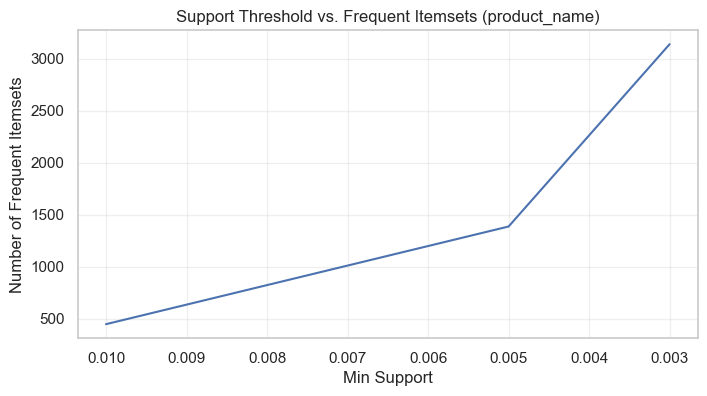

### Hyperparameter Sweep: **AISLE**

- Support `0.05`: Found `429` itemsets in `0.26s`

- Support `0.02`: Found `1906` itemsets in `0.45s`

- Support `0.01`: Found `5105` itemsets in `0.92s`

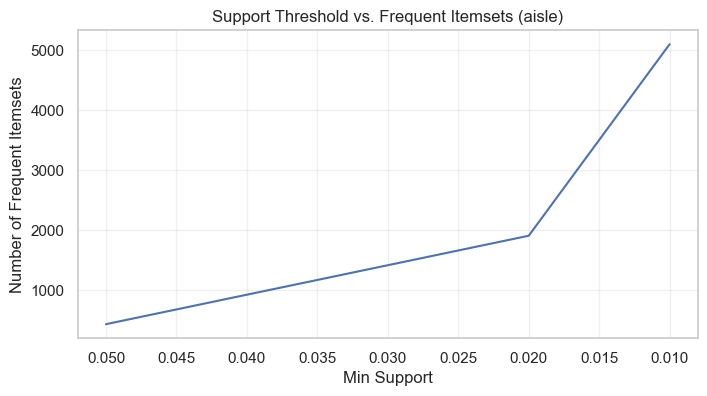

### Hyperparameter Sweep: **DEPARTMENT**

- Support `0.2`: Found `66` itemsets in `0.06s`

- Support `0.1`: Found `267` itemsets in `0.10s`

- Support `0.075`: Found `416` itemsets in `0.12s`

- Support `0.05`: Found `672` itemsets in `0.17s`

- Support `0.025`: Found `1165` itemsets in `0.25s`

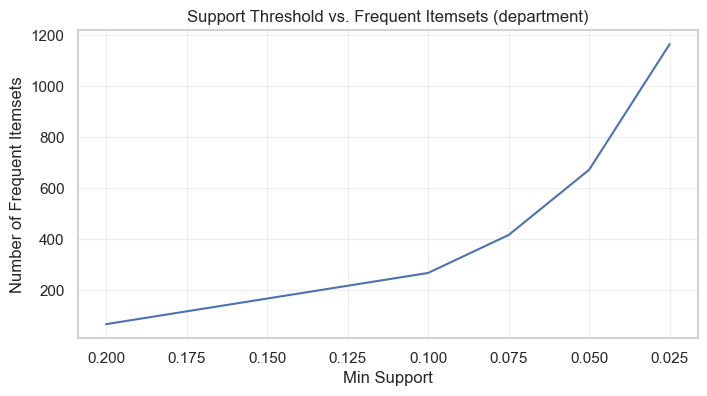

In [3]:
df_merged = load_and_prep_data()
df_subset = df_merged.sample(n=100000, random_state=42)
find_support_elbow(df_subset, level='product_name', thresholds=[0.01, 0.005, 0.003]) 
find_support_elbow(df_subset, level='aisle', thresholds=[0.05, 0.02, 0.01])
find_support_elbow(df_subset, level='department', thresholds=[0.2, 0.1, 0.075, 0.05, 0.025])

## Exploratory Data Analysis

--- Missing Values Check ---

,Missing Count
product_name,0
aisle,0
department,0
order_hour_of_day,0
order_dow,0


- **Total transactions (orders):** `10,000`
- **Total unique products:** `16,561`

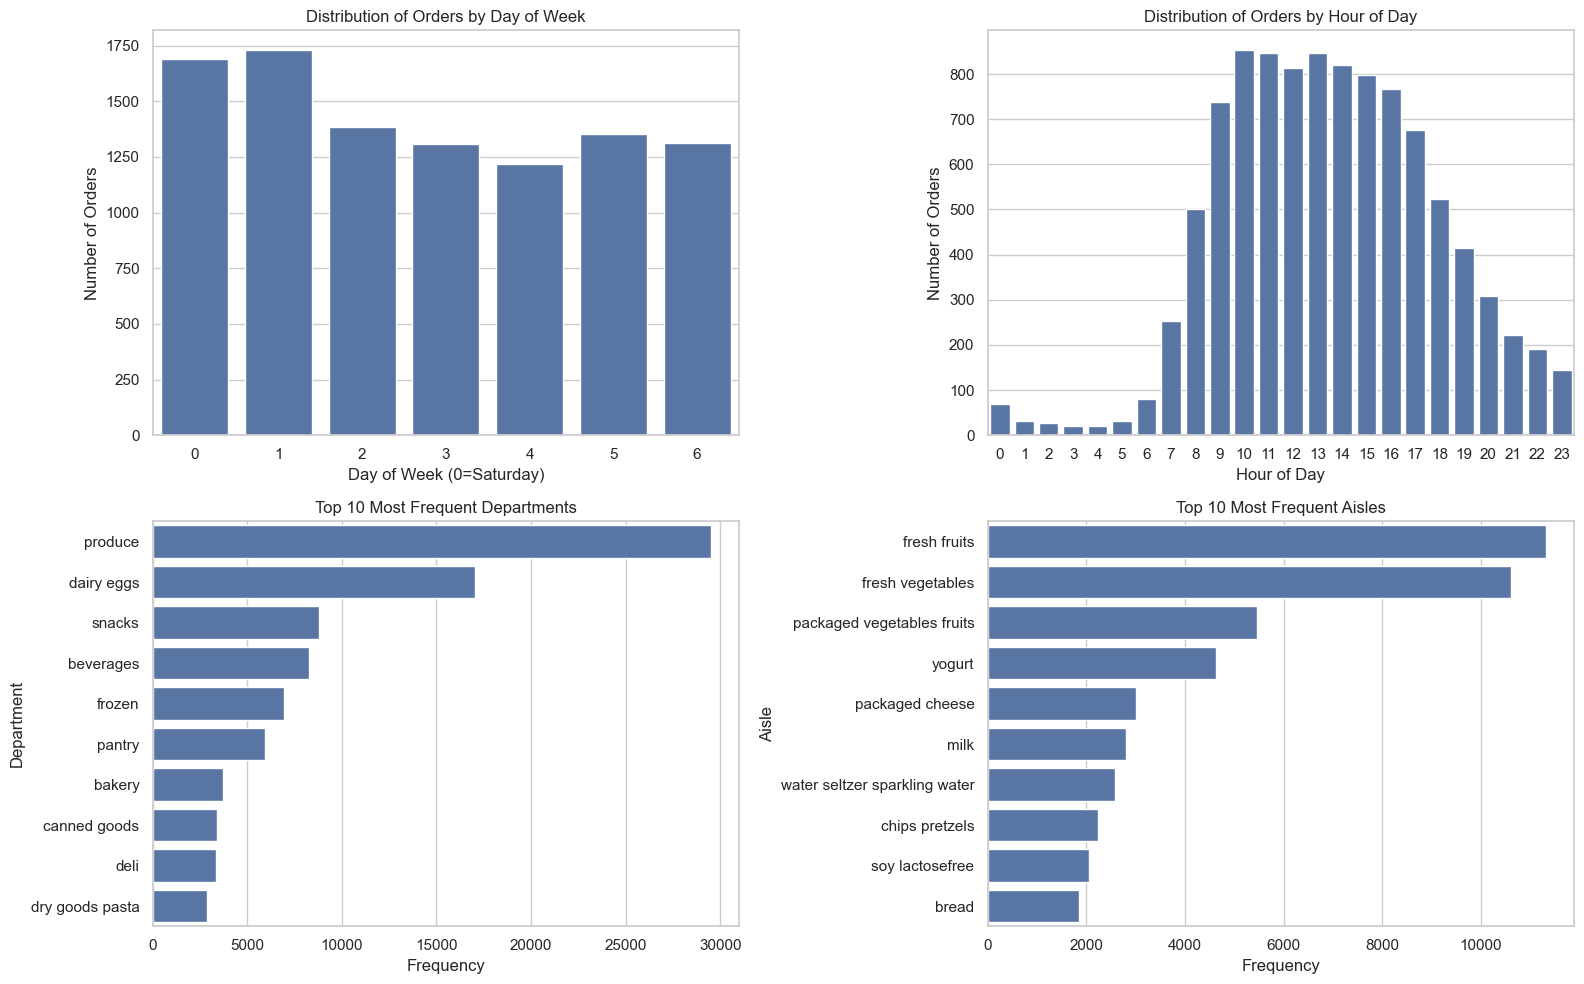

### Top 10 Products by Reorder Loyalty

product_name
\"Constant Comment\" Black Tea                                    1.0
Ziti Bolognese Pasta Bowl                                         1.0
Zita Cut, No. 118                                                 1.0
Zinfandel                                                         1.0
1.5% Milkfat Grade A Pasteurized Lowfat Cottage Cheese            1.0
1,000 mg Vitamin C Lemon-Lime Flavored Fizzy Drink Mix - 30 PK    1.0
1% Milkfat Low Fat Vitamin A & D Milk                             1.0
1% Chocolate Milk                                                 1.0
Zesty Sriracha Carrot Hummus                                      1.0
Zesty Garlic Aiolo Mayo Alternative                               1.0
Name: reordered, dtype: float64

<br>

---
## DIMENSION: **WEEKEND**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.05)*

- **Rules Found:** `19,524`
- **Unique Rules:** `19,524`
- **Robust Rules:** `210`

**Performance:** Apriori took `0.29s` | FP-Growth took `0.05s` *(FP-Growth is **6.1x** faster)*

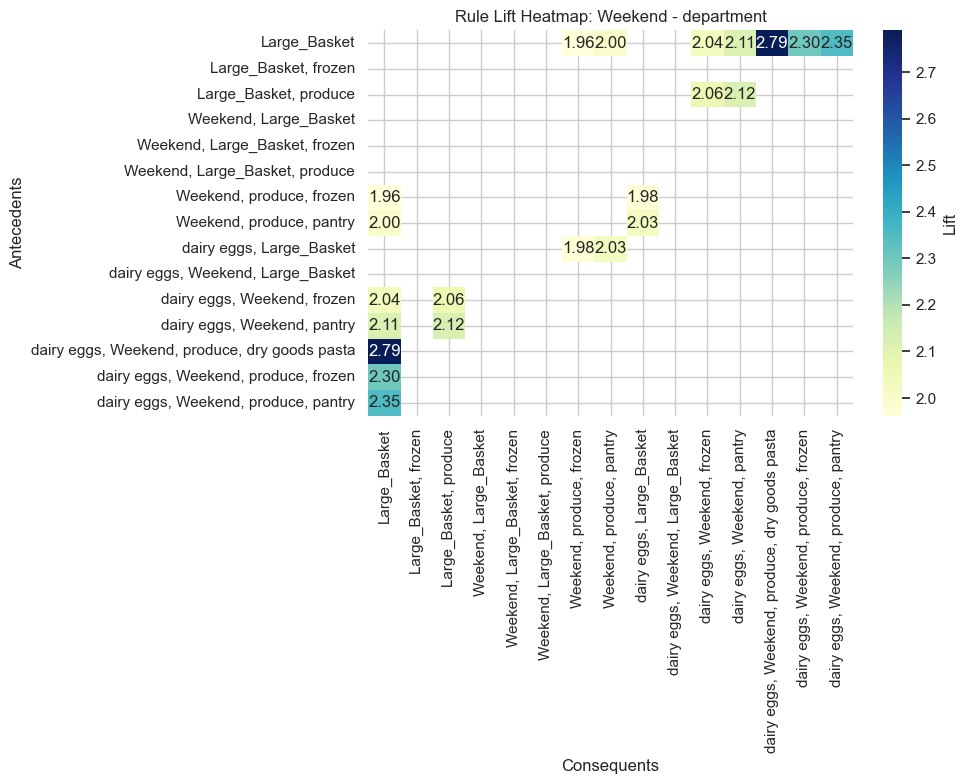

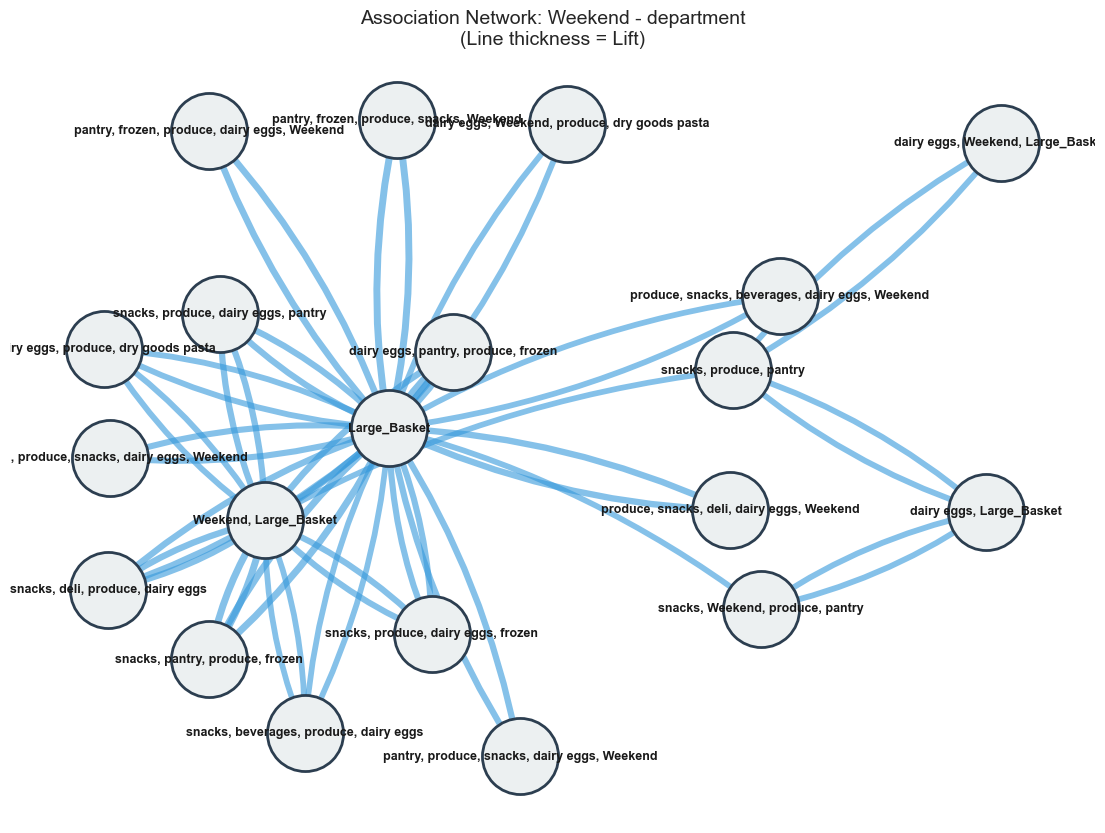

---

### LEVEL: **AISLE** *(Min Support: 0.01)*

- **Rules Found:** `265,566`
- **Unique Rules:** `197,250`
- **Robust Rules:** `66`

**Performance:** Apriori took `2.76s` | FP-Growth took `0.46s` *(FP-Growth is **6.0x** faster)*

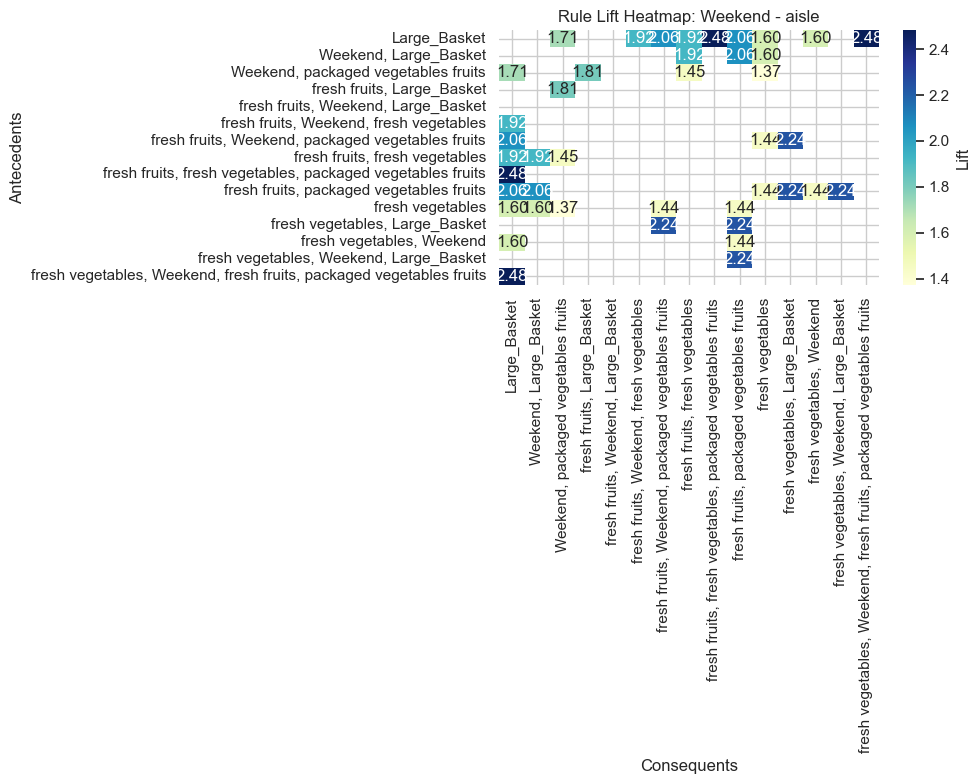

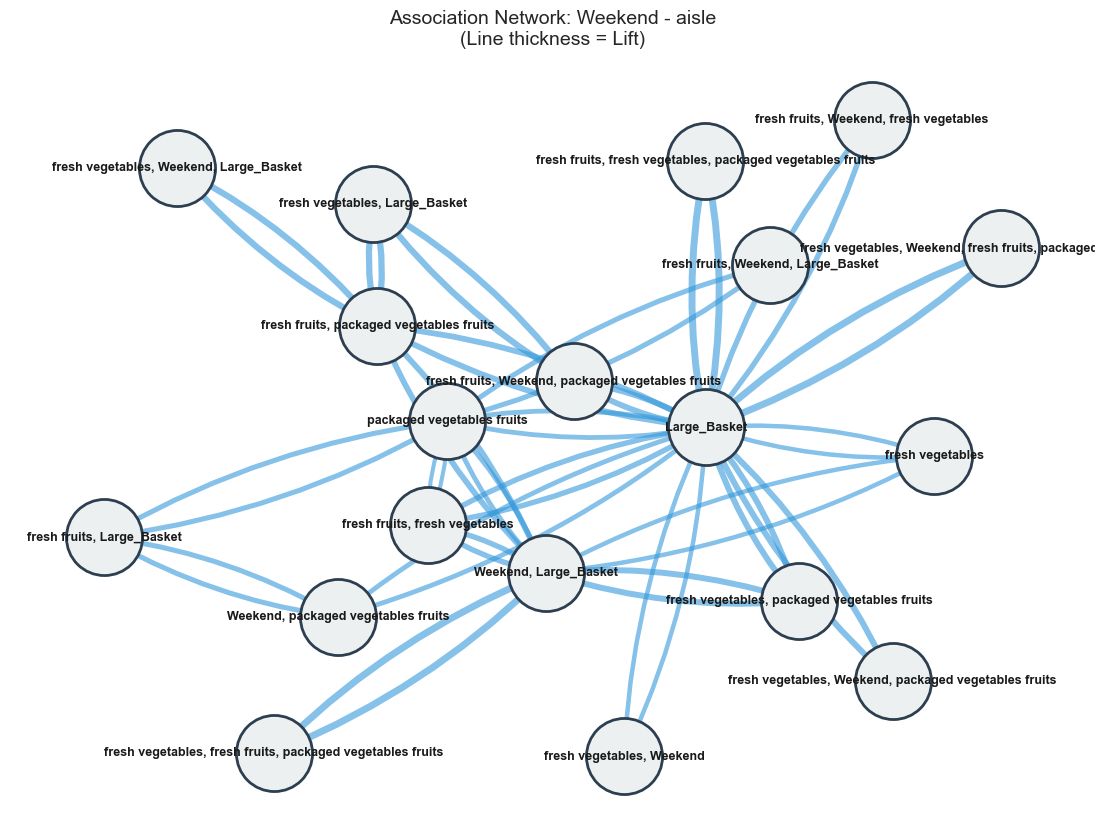

---

### LEVEL: **PRODUCT_NAME** *(Min Support: 0.002)*

- **Rules Found:** `39,840`
- **Unique Rules:** `21,240`
- **Robust Rules:** `96`

**Performance:** Apriori took `2.27s` | FP-Growth took `0.42s` *(FP-Growth is **5.4x** faster)*

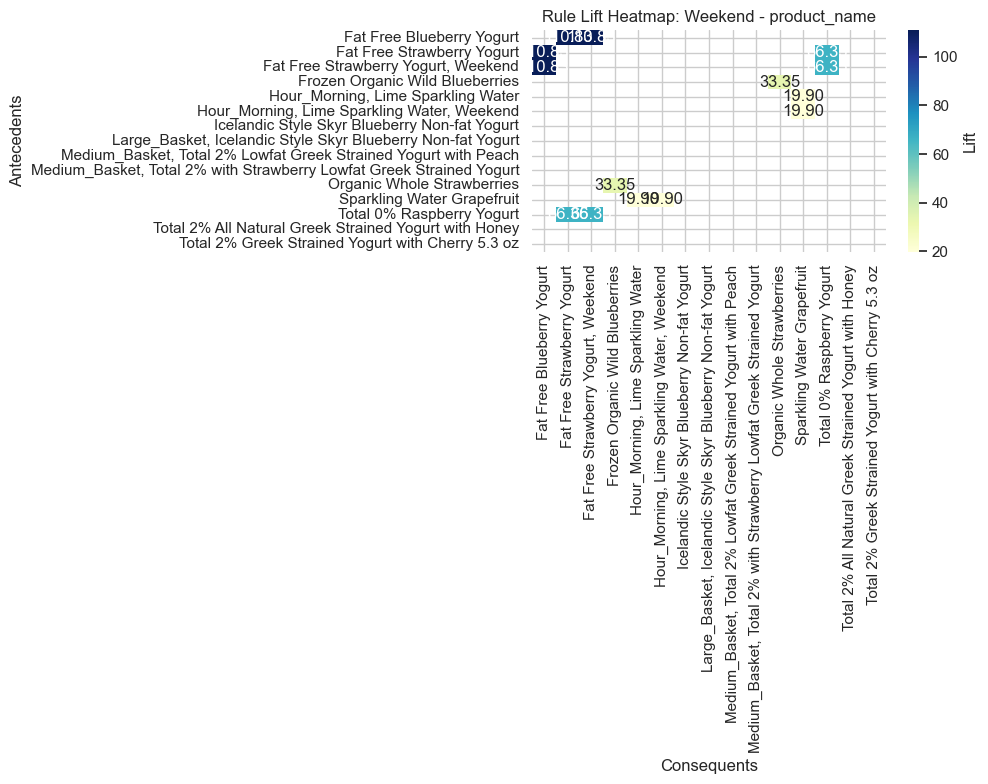

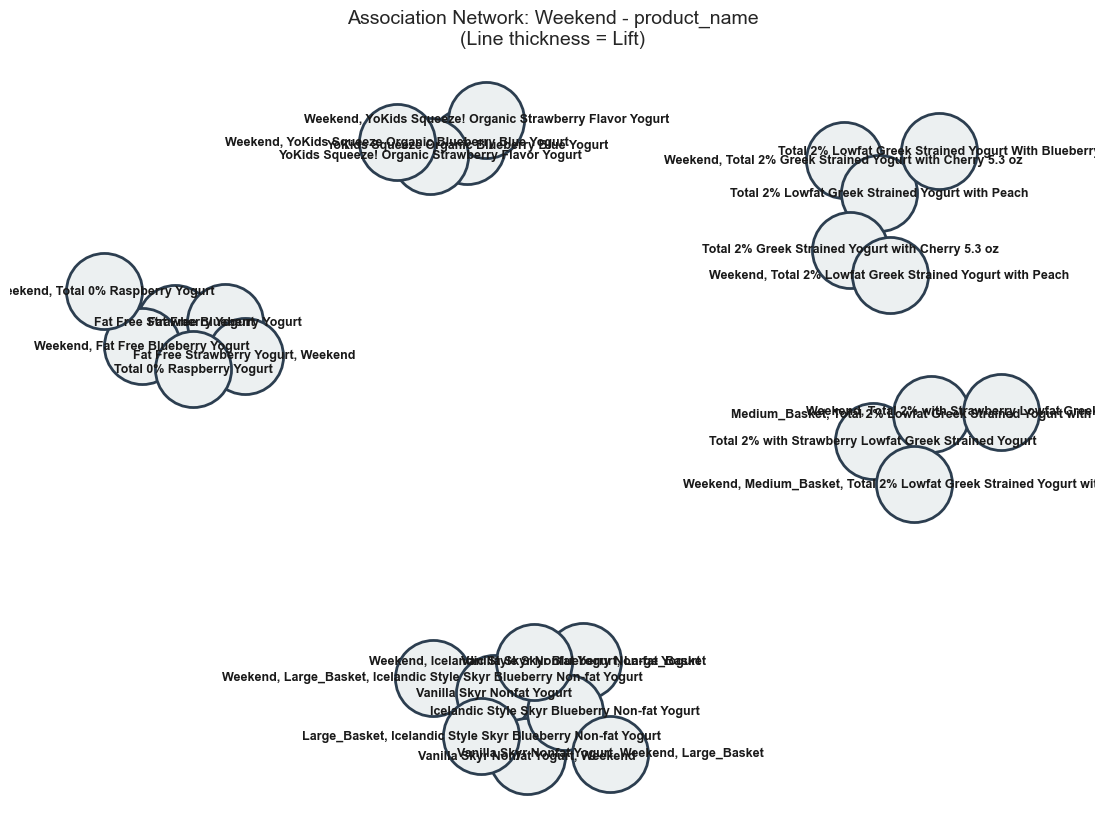

---

<br>

---
## DIMENSION: **WEEKDAY**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.05)*

- **Rules Found:** `13,884`
- **Unique Rules:** `13,884`
- **Robust Rules:** `132`

**Performance:** Apriori took `0.35s` | FP-Growth took `0.10s` *(FP-Growth is **3.5x** faster)*

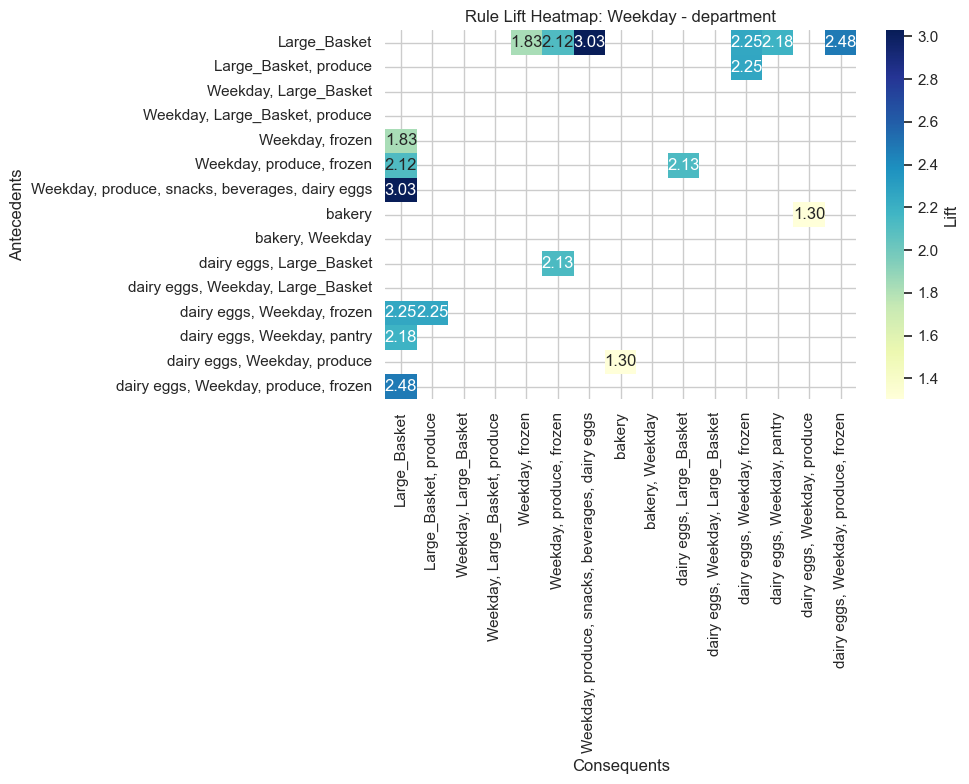

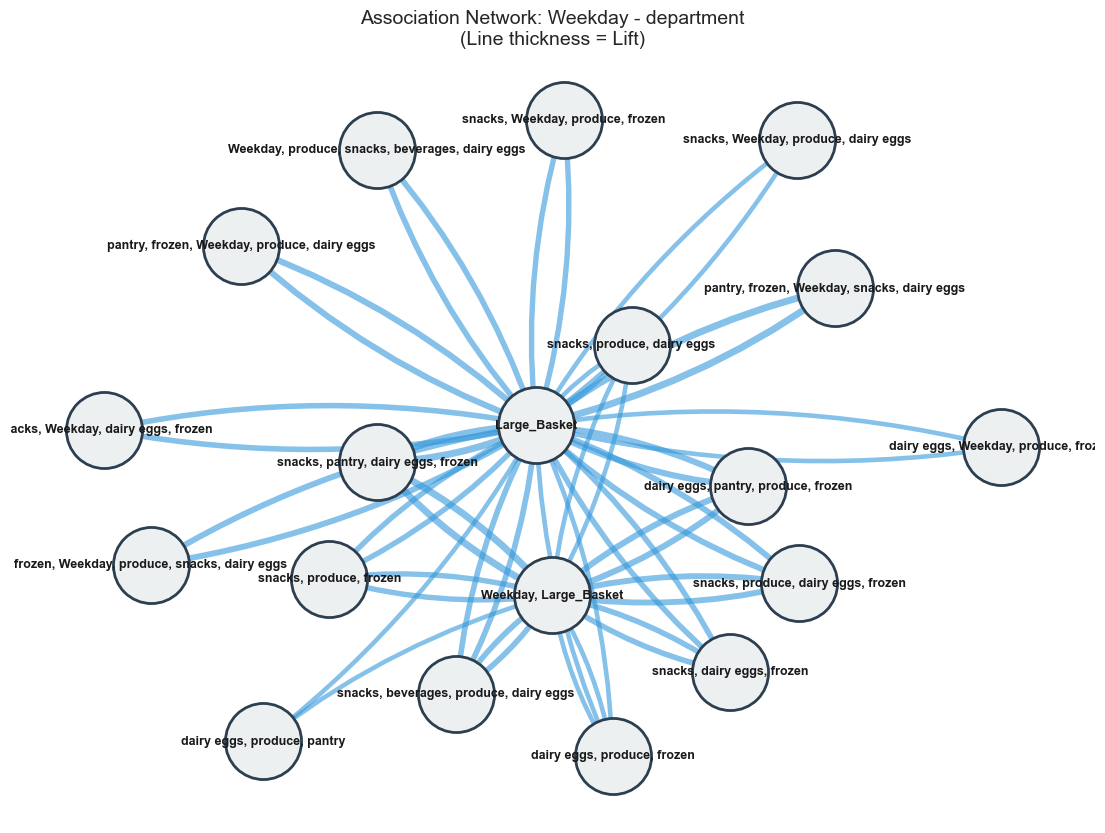

---

### LEVEL: **AISLE** *(Min Support: 0.01)*

- **Rules Found:** `183,918`
- **Unique Rules:** `141,240`
- **Robust Rules:** `72`

**Performance:** Apriori took `2.59s` | FP-Growth took `0.69s` *(FP-Growth is **3.7x** faster)*

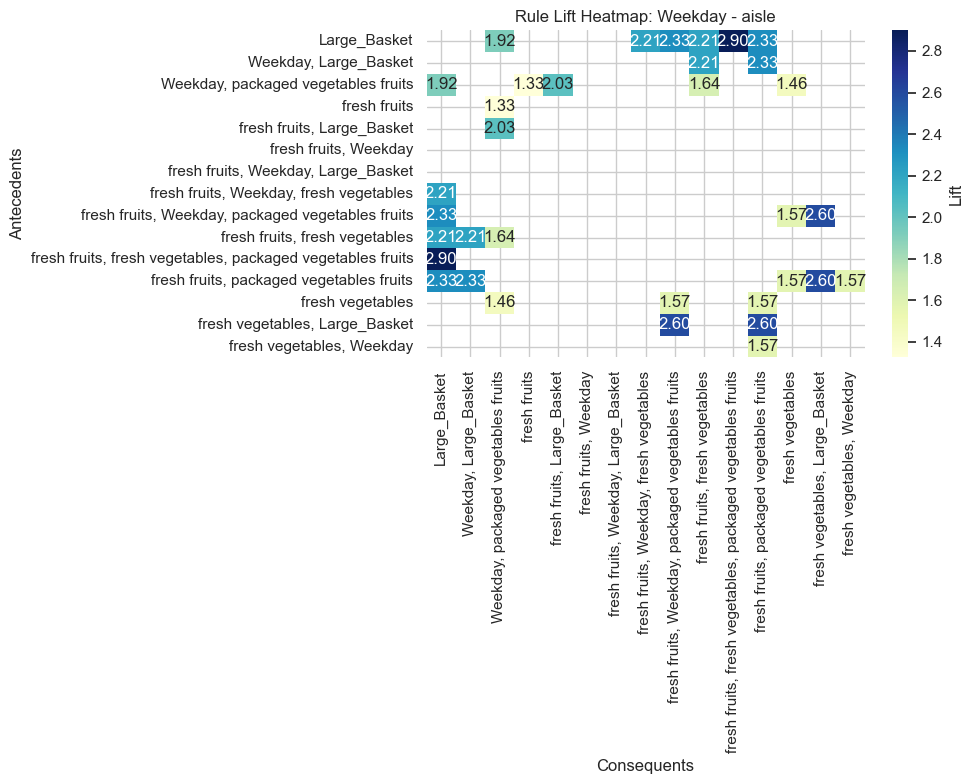

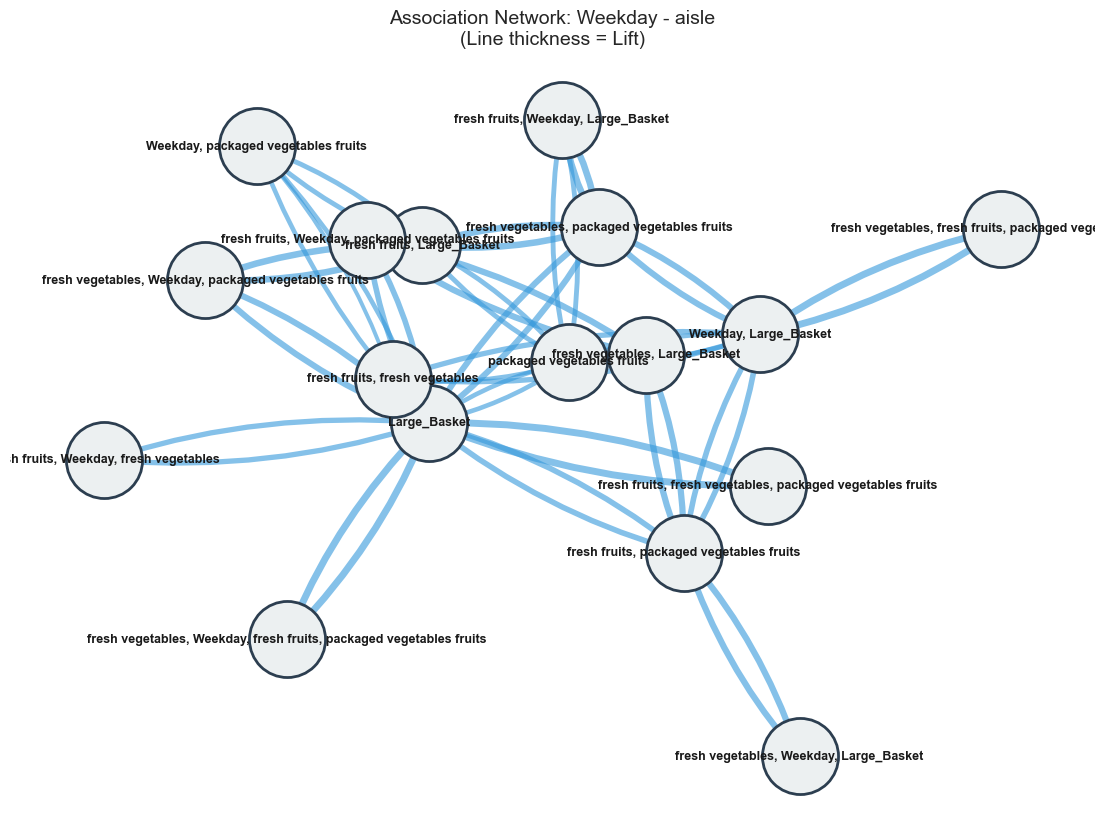

---

### LEVEL: **PRODUCT_NAME** *(Min Support: 0.002)*

- **Rules Found:** `16,350`
- **Unique Rules:** `7,320`
- **Robust Rules:** `72`

**Performance:** Apriori took `2.10s` | FP-Growth took `0.68s` *(FP-Growth is **3.1x** faster)*

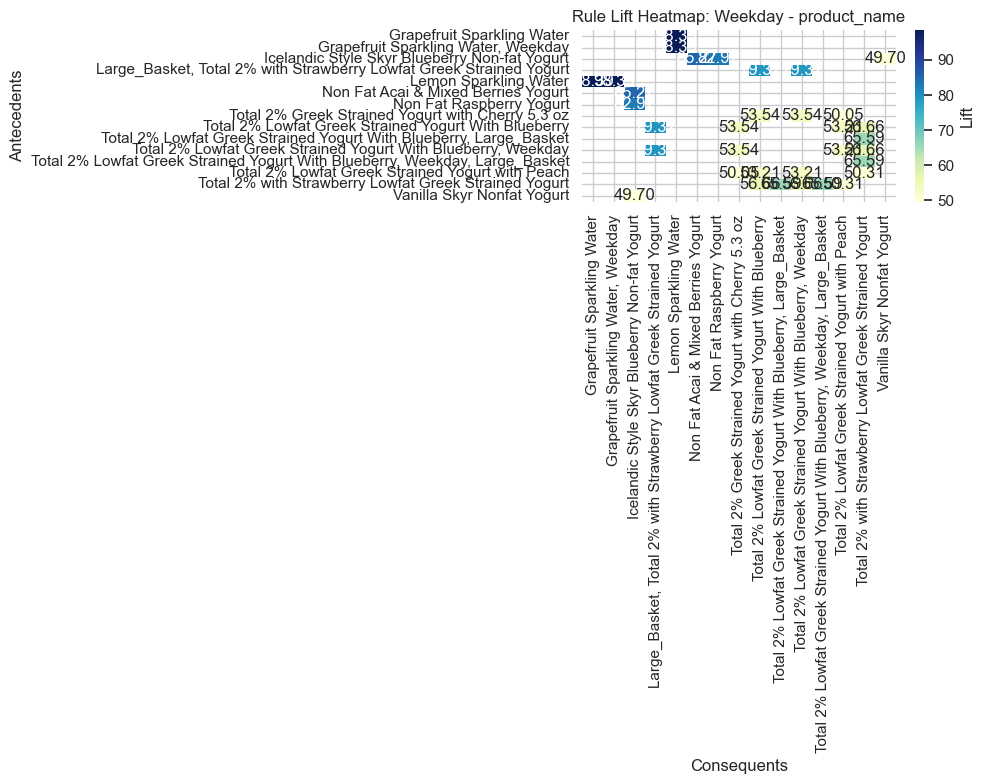

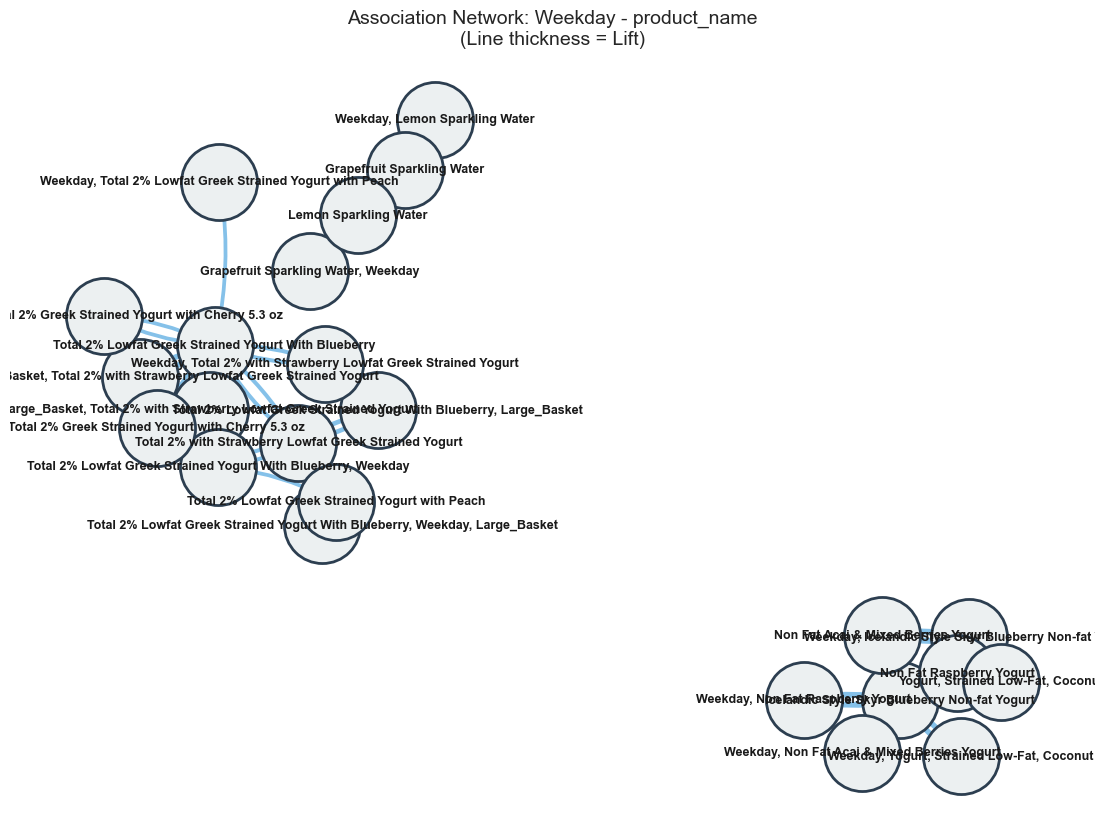

---

<br>

---
## DIMENSION: **HOUR_MORNING**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.05)*

- **Rules Found:** `21,054`
- **Unique Rules:** `21,054`
- **Robust Rules:** `216`

**Performance:** Apriori took `0.35s` | FP-Growth took `0.07s` *(FP-Growth is **5.1x** faster)*

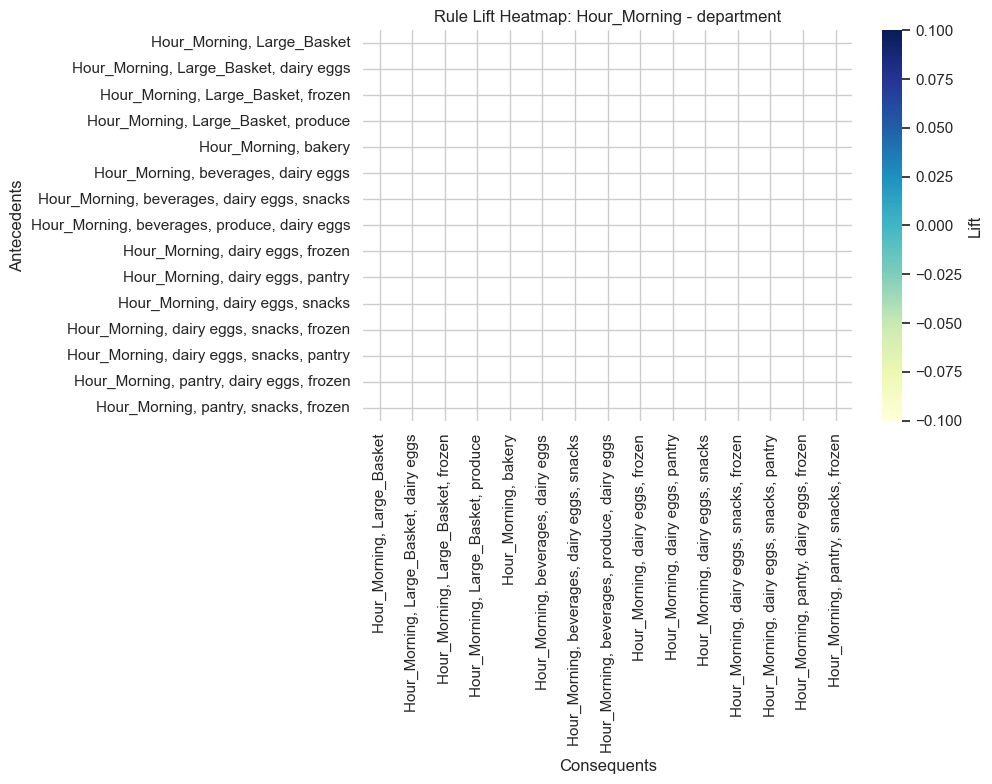

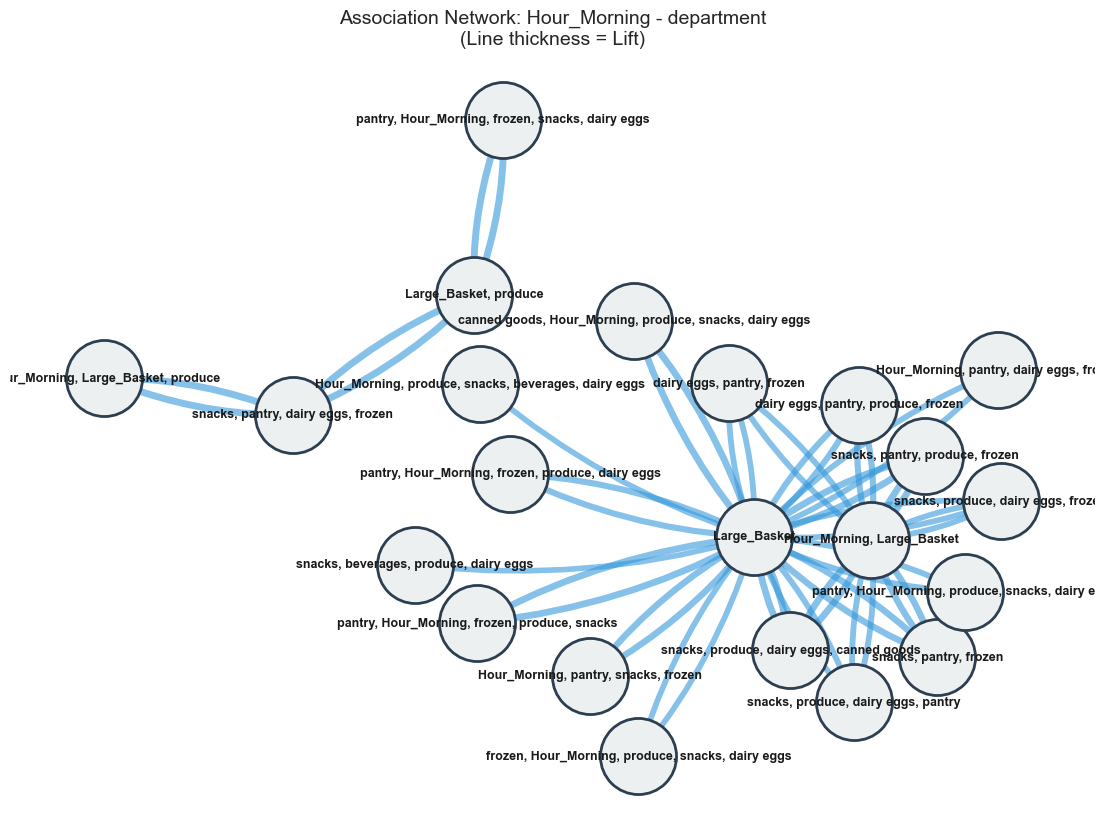

---

### LEVEL: **AISLE** *(Min Support: 0.01)*

- **Rules Found:** `280,098`
- **Unique Rules:** `213,090`
- **Robust Rules:** `78`

**Performance:** Apriori took `2.71s` | FP-Growth took `0.47s` *(FP-Growth is **5.7x** faster)*

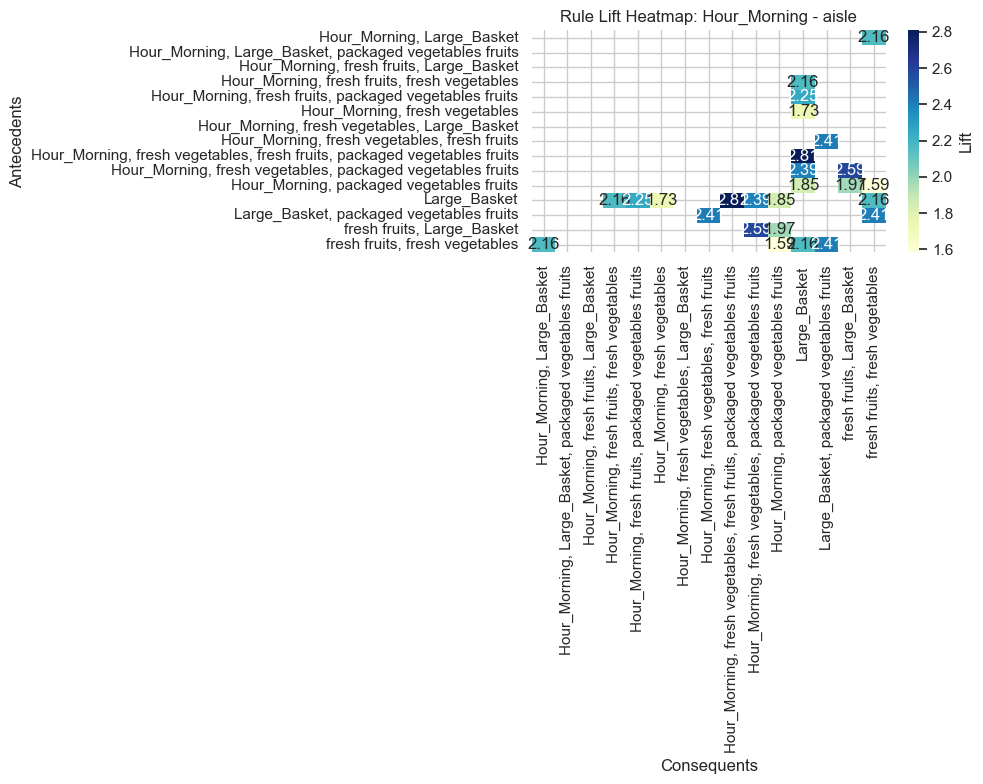

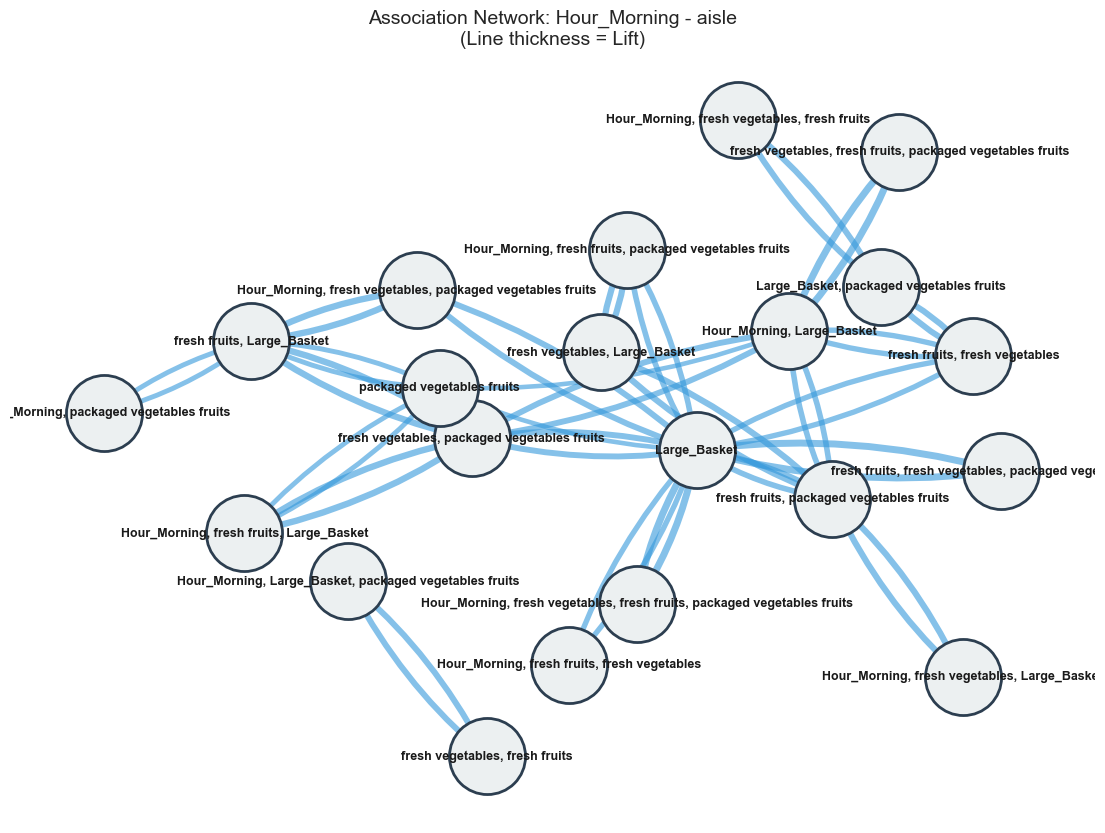

---

### LEVEL: **PRODUCT_NAME** *(Min Support: 0.002)*

- **Rules Found:** `34,866`
- **Unique Rules:** `18,312`
- **Robust Rules:** `354`

**Performance:** Apriori took `2.01s` | FP-Growth took `0.38s` *(FP-Growth is **5.3x** faster)*

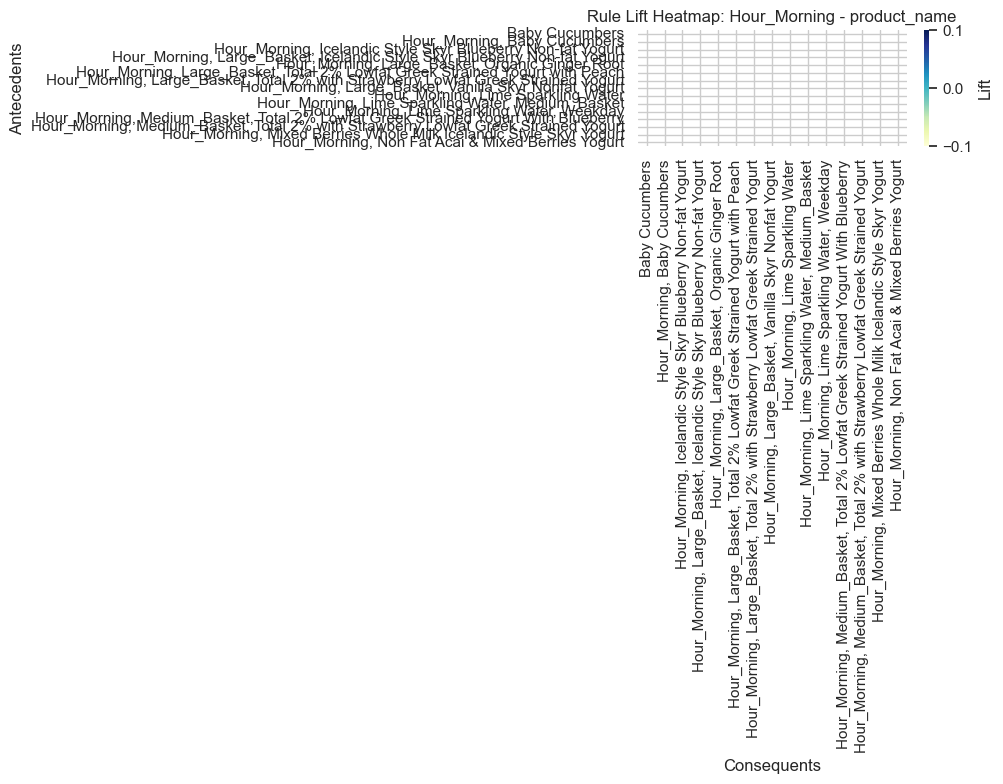

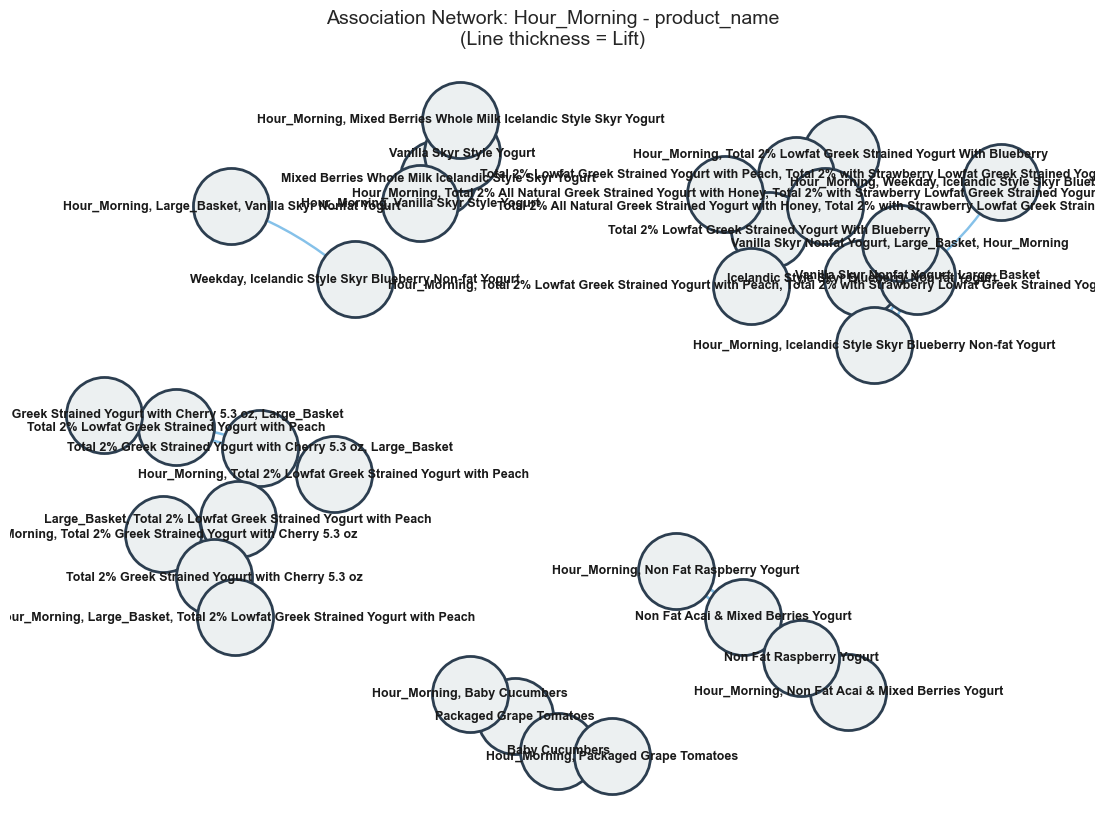

---

<br>

---
## DIMENSION: **HOUR_AFTERNOON**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.05)*

- **Rules Found:** `18,204`
- **Unique Rules:** `18,204`
- **Robust Rules:** `114`

**Performance:** Apriori took `0.32s` | FP-Growth took `0.16s` *(FP-Growth is **1.9x** faster)*

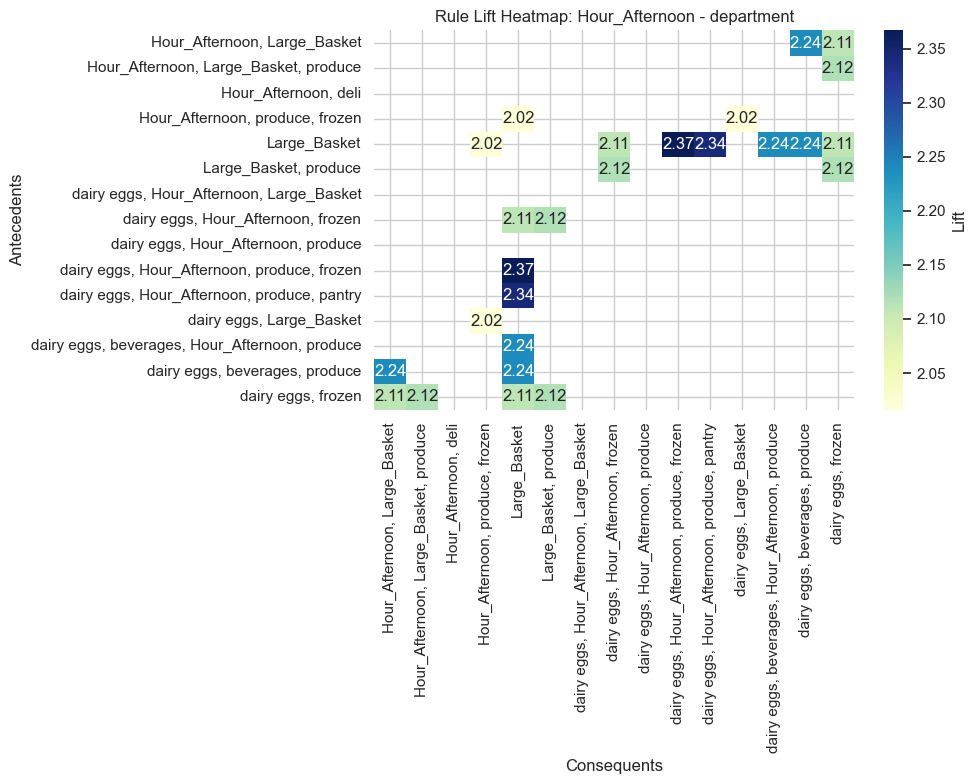

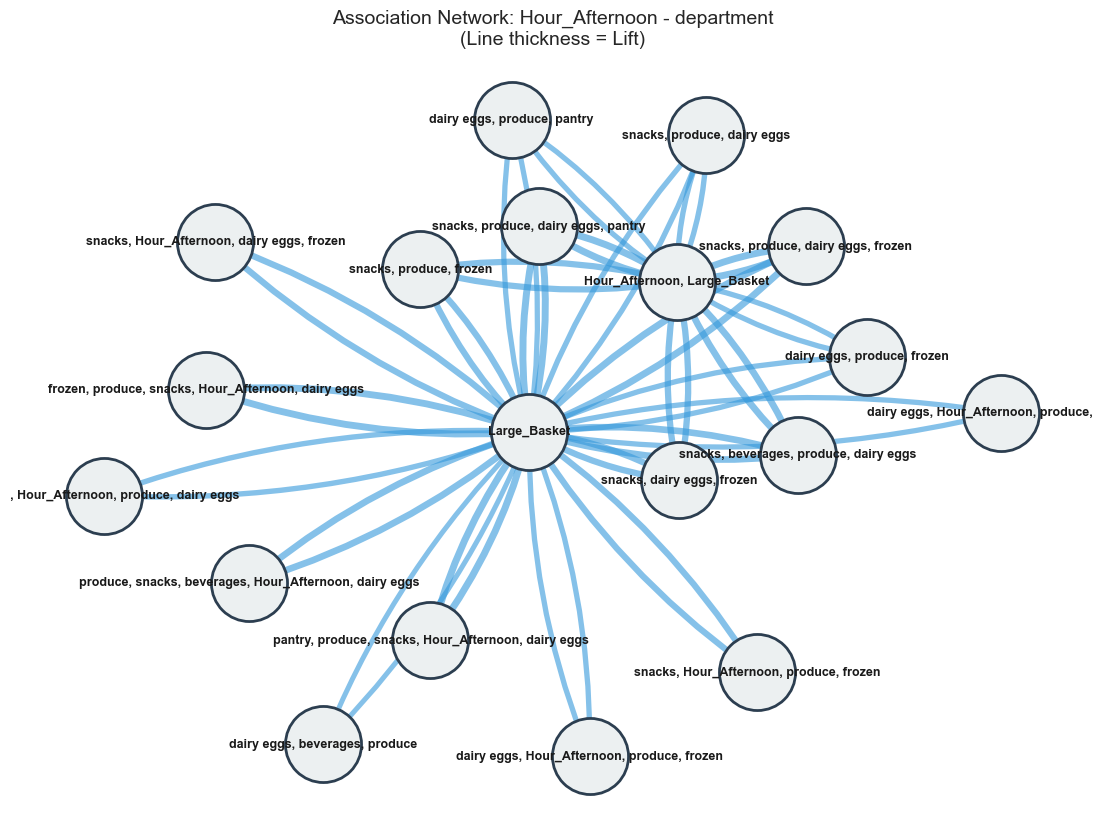

---

### LEVEL: **AISLE** *(Min Support: 0.01)*

- **Rules Found:** `247,830`
- **Unique Rules:** `187,668`
- **Robust Rules:** `72`

**Performance:** Apriori took `2.60s` | FP-Growth took `0.63s` *(FP-Growth is **4.1x** faster)*

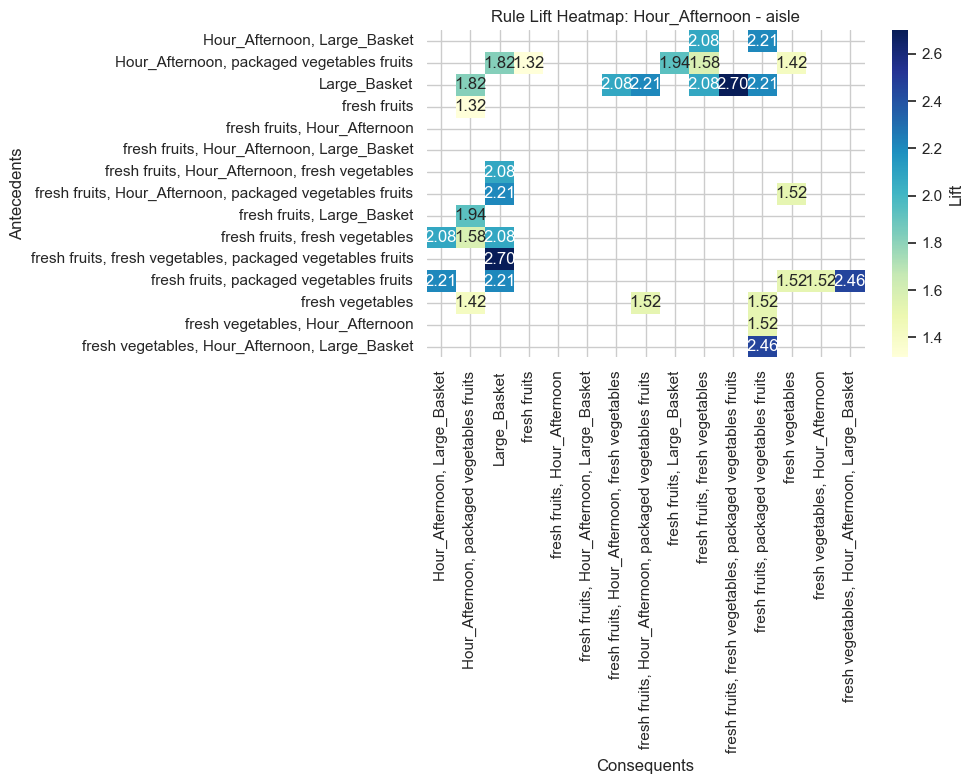

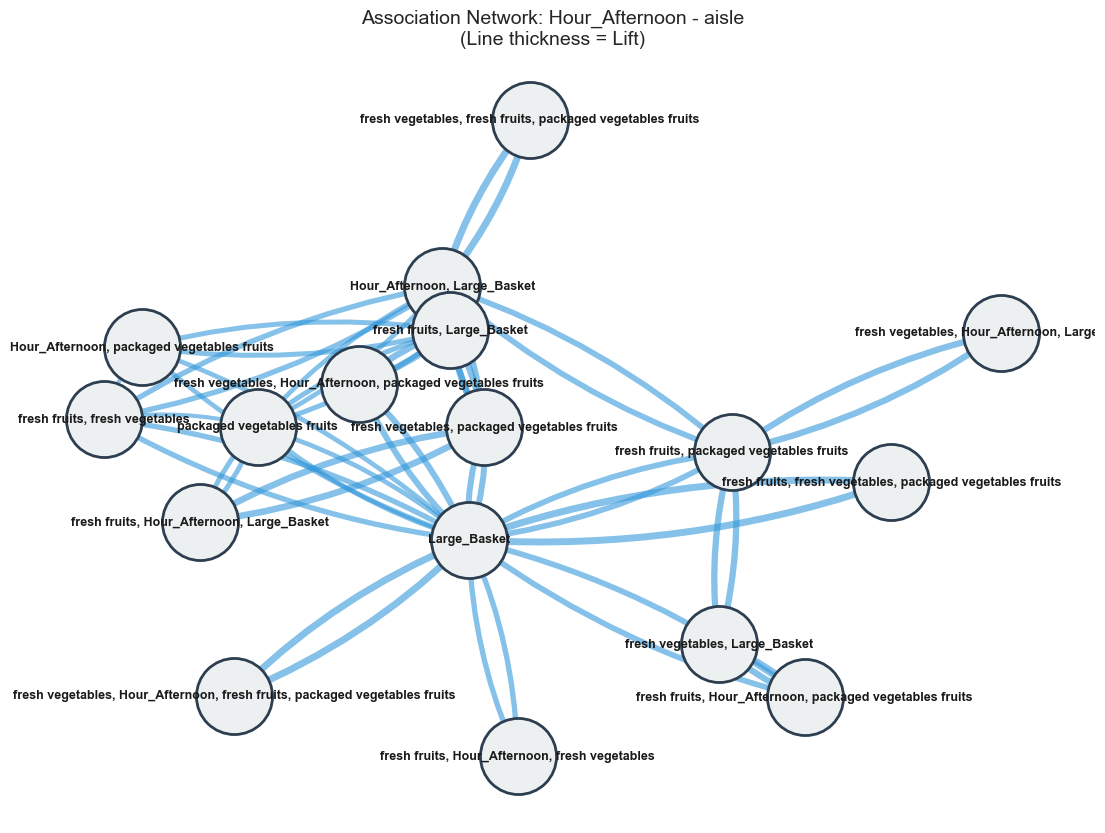

---

### LEVEL: **PRODUCT_NAME** *(Min Support: 0.002)*

- **Rules Found:** `24,258`
- **Unique Rules:** `11,190`
- **Robust Rules:** `24`

**Performance:** Apriori took `1.97s` | FP-Growth took `0.68s` *(FP-Growth is **2.9x** faster)*

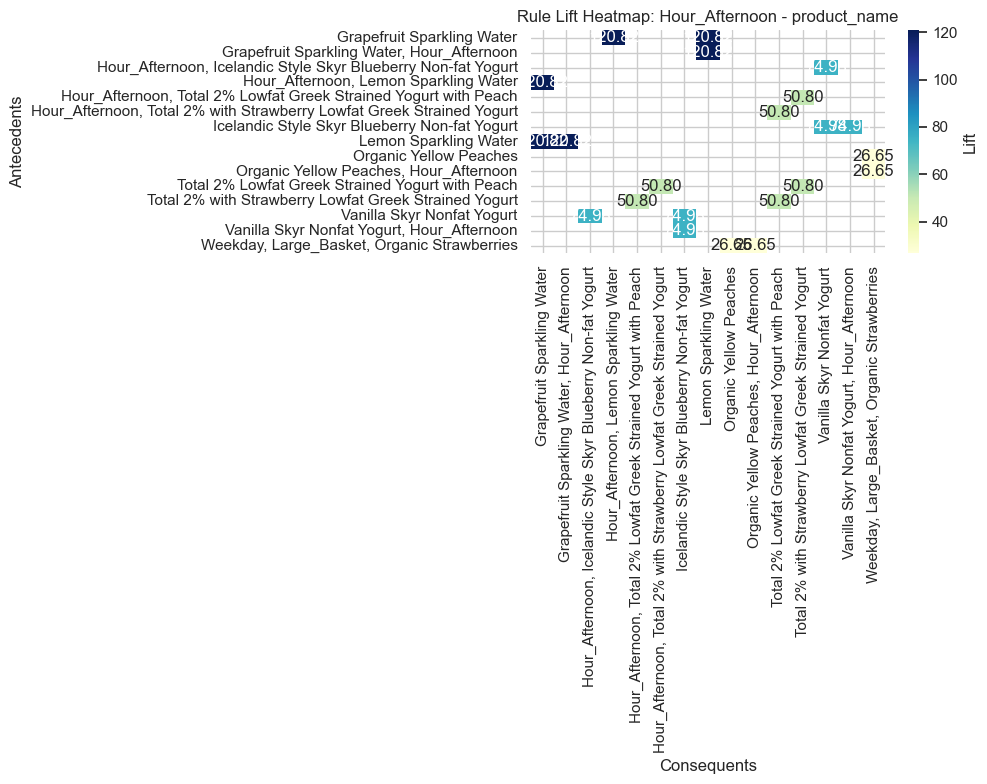

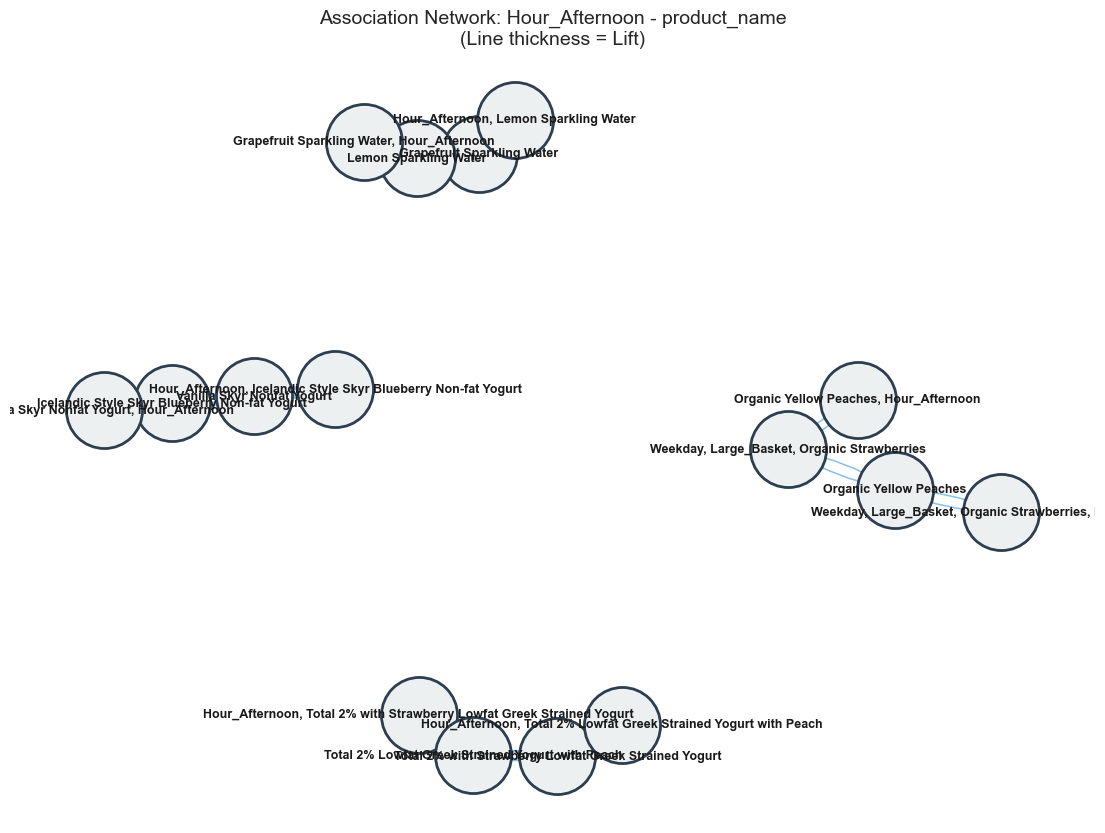

---

<br>

---
## DIMENSION: **HOUR_EVENING**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.05)*

- **Rules Found:** `21,738`
- **Unique Rules:** `21,738`
- **Robust Rules:** `348`

**Performance:** Apriori took `0.31s` | FP-Growth took `0.03s` *(FP-Growth is **9.2x** faster)*

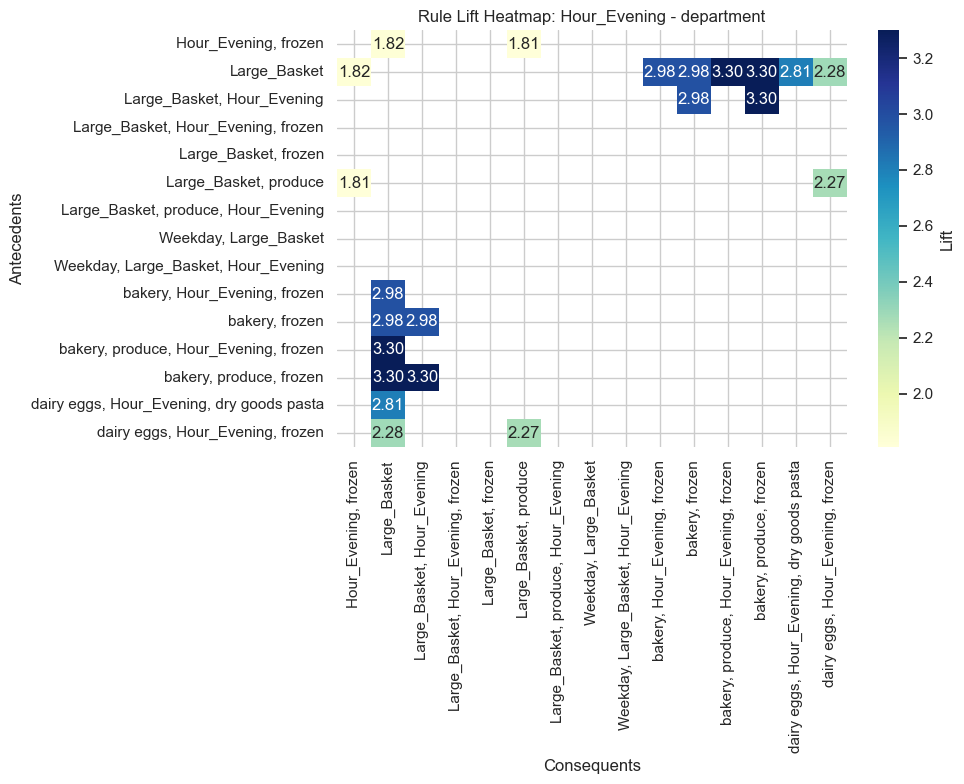

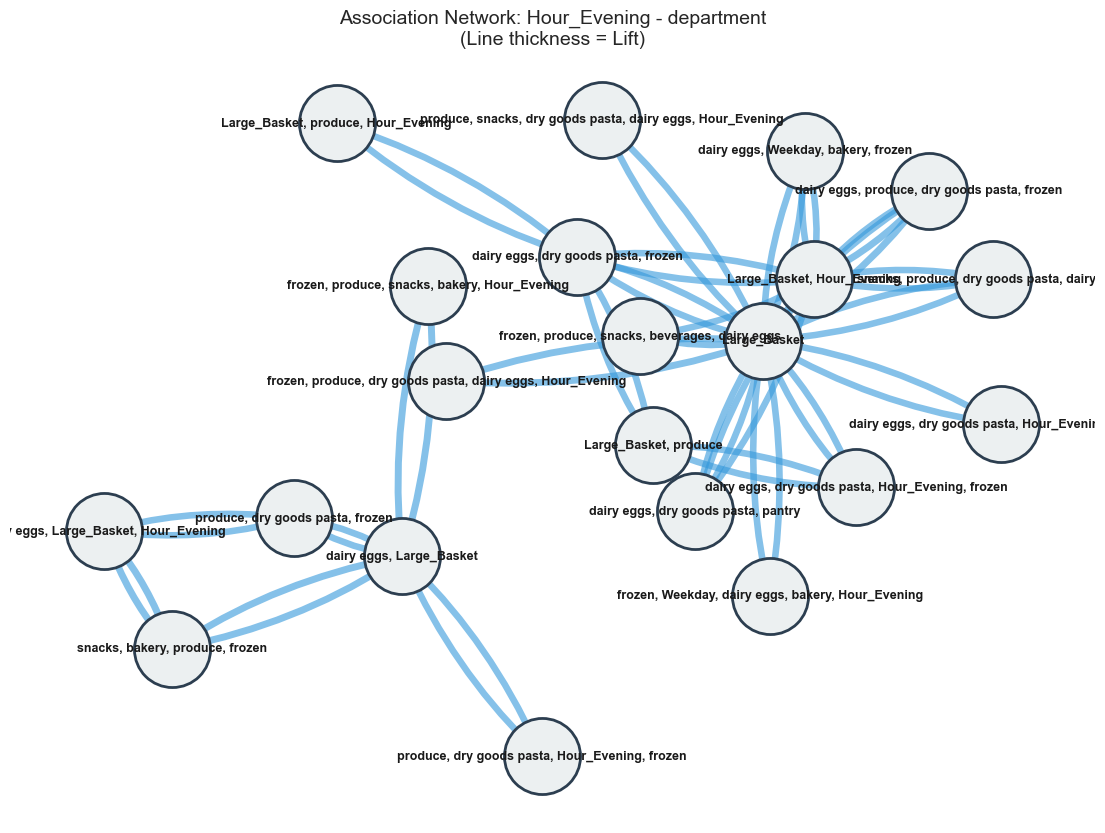

---

### LEVEL: **AISLE** *(Min Support: 0.01)*

- **Rules Found:** `307,002`
- **Unique Rules:** `229,836`
- **Robust Rules:** `72`

**Performance:** Apriori took `2.40s` | FP-Growth took `0.33s` *(FP-Growth is **7.2x** faster)*

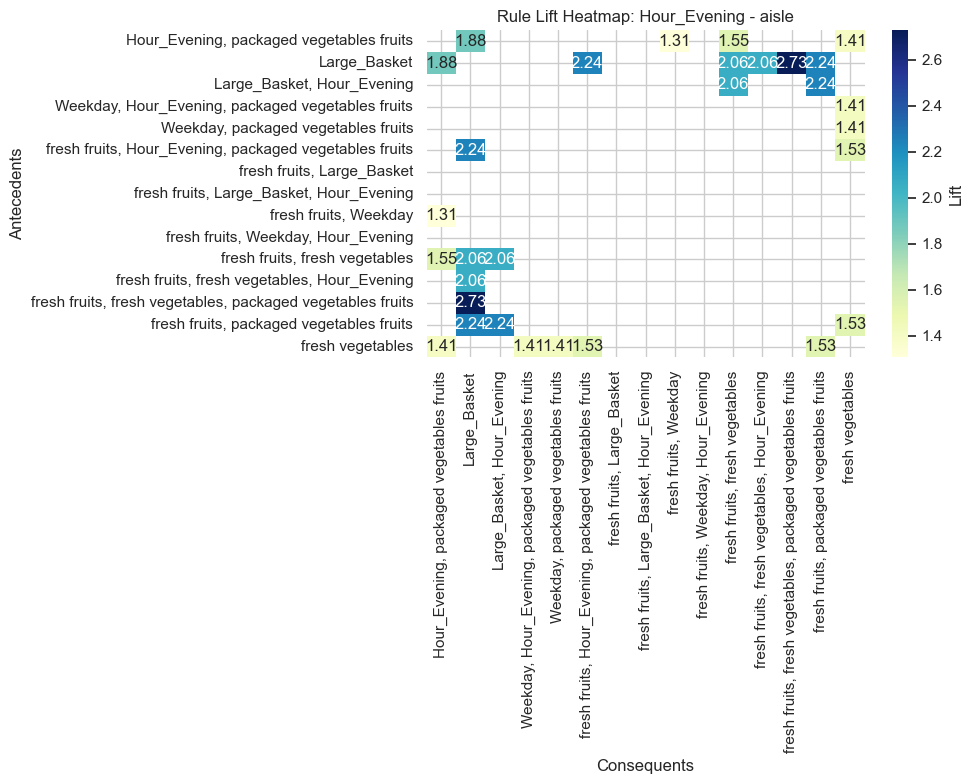

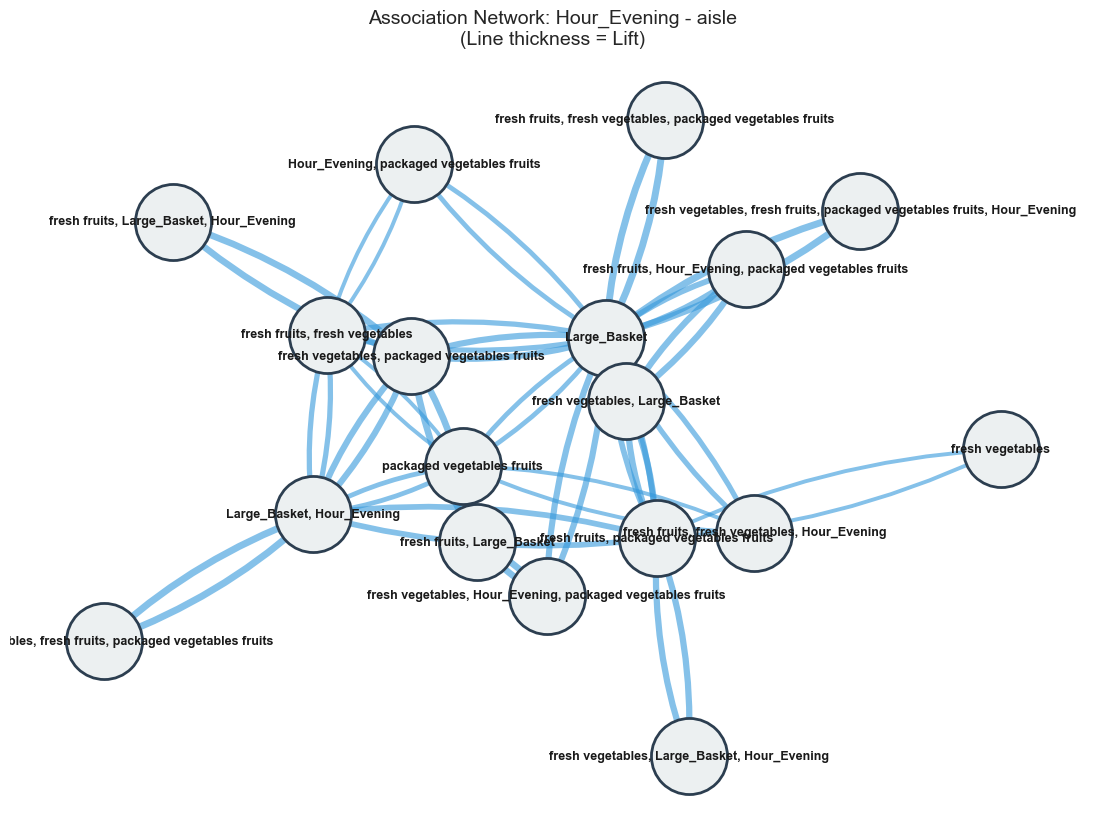

---

### LEVEL: **PRODUCT_NAME** *(Min Support: 0.002)*

- **Rules Found:** `61,548`
- **Unique Rules:** `33,828`
- **Robust Rules:** `372`

**Performance:** Apriori took `2.28s` | FP-Growth took `0.32s` *(FP-Growth is **7.2x** faster)*

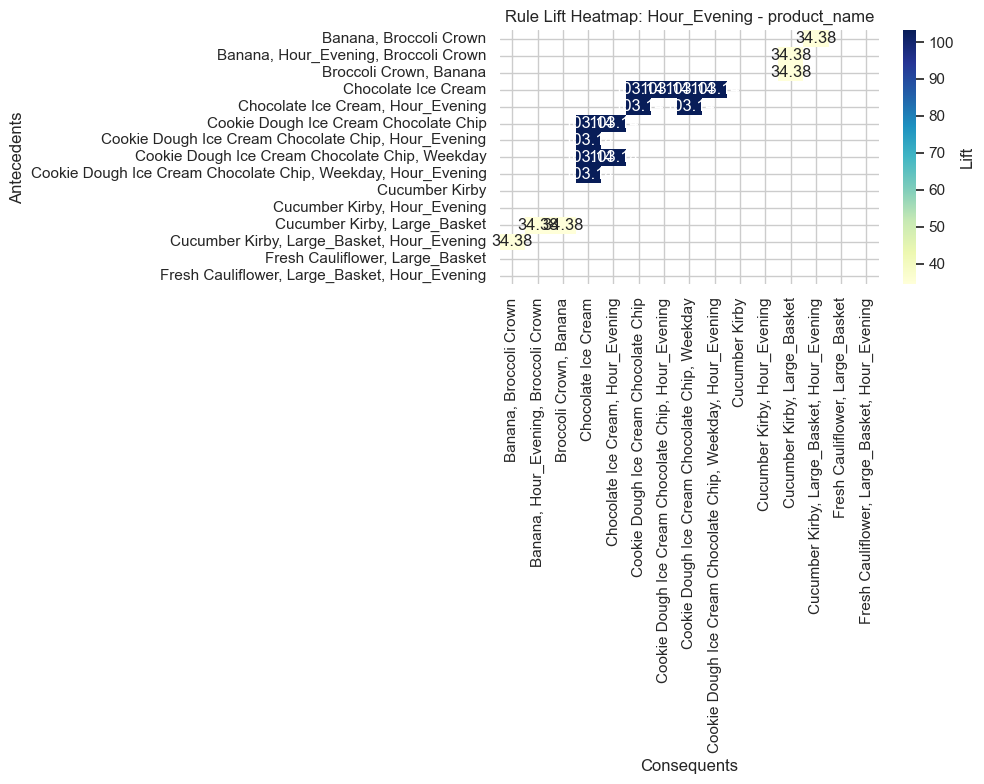

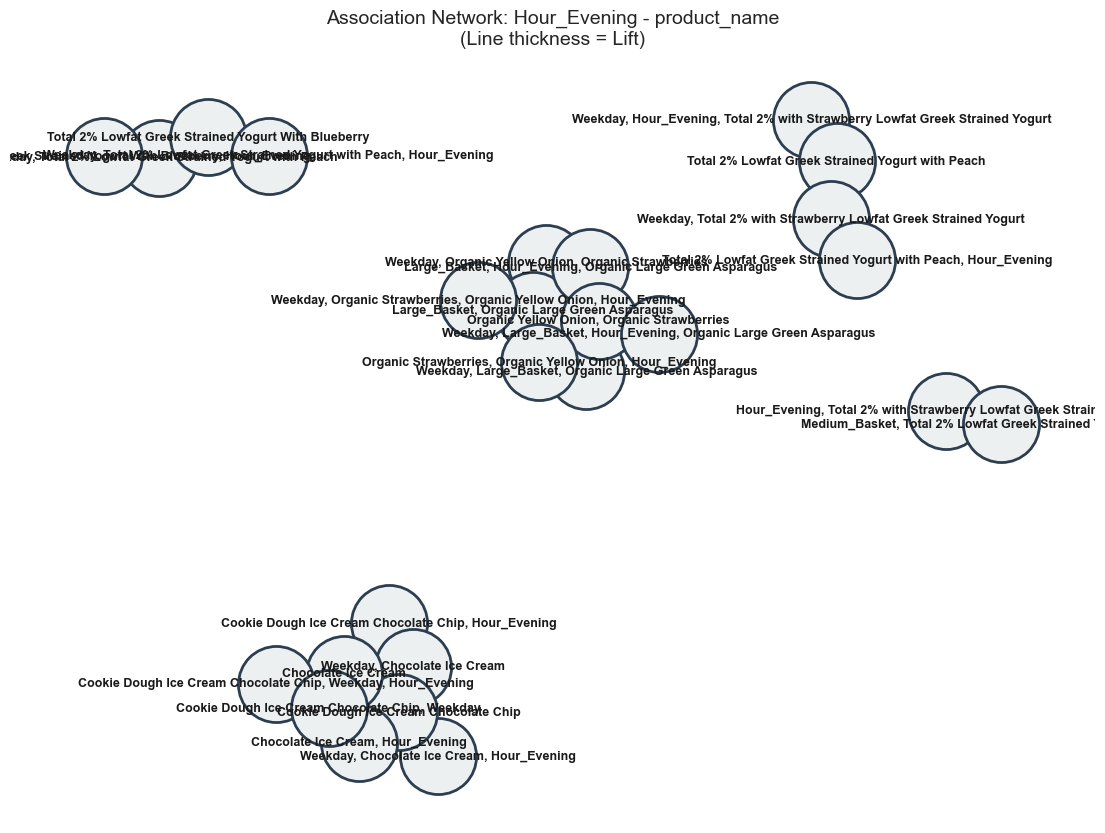

---

<br>

---
## DIMENSION: **HOUR_NIGHT**
---

### LEVEL: **DEPARTMENT** *(Min Support: 0.05)*

- **Rules Found:** `40,824`
- **Unique Rules:** `40,824`
- **Robust Rules:** `3,264`

**Performance:** Apriori took `0.40s` | FP-Growth took `0.03s` *(FP-Growth is **13.7x** faster)*

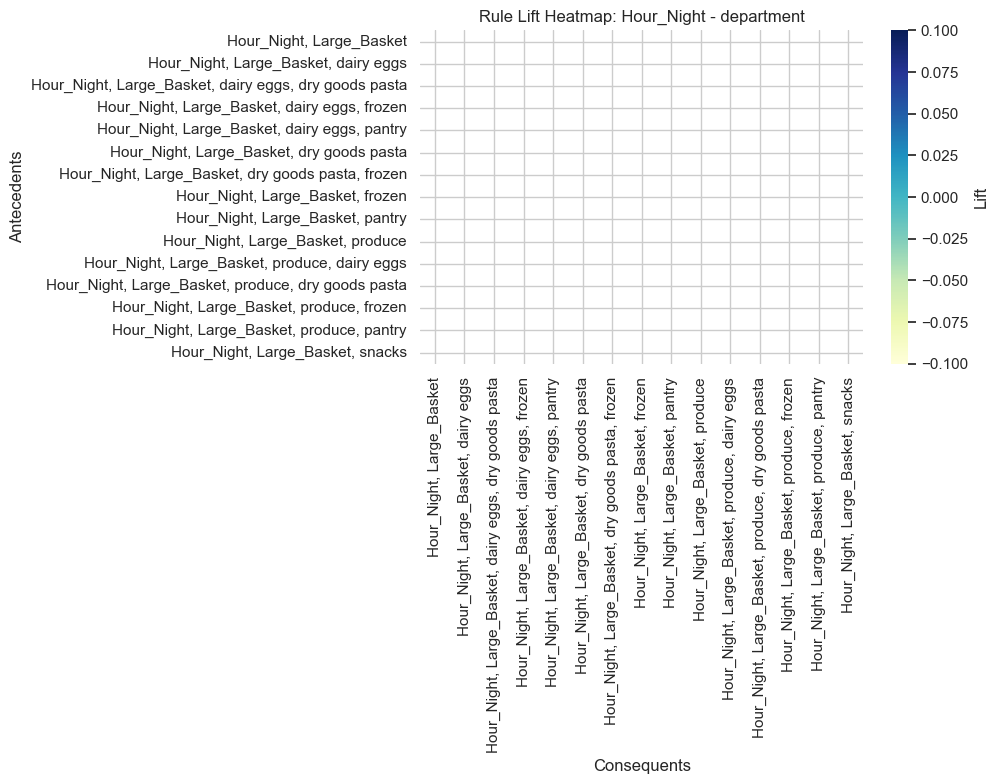

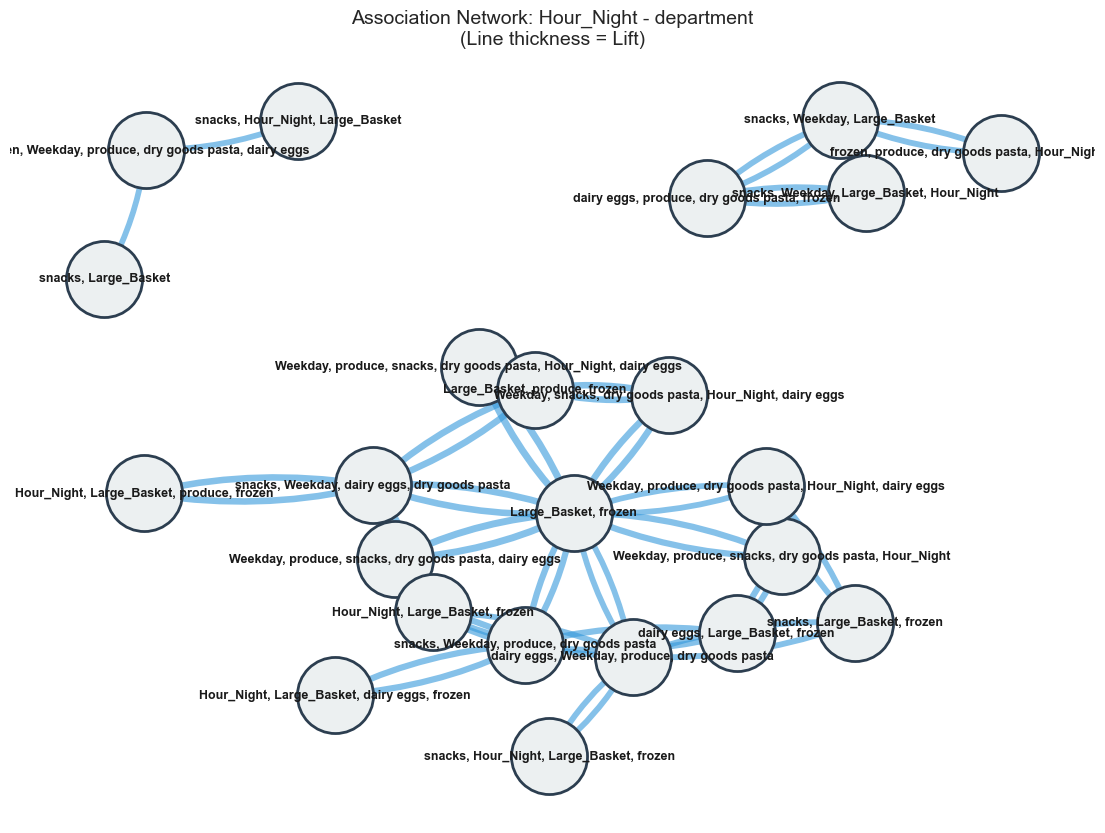

---

## Algorithm Performance Comparison

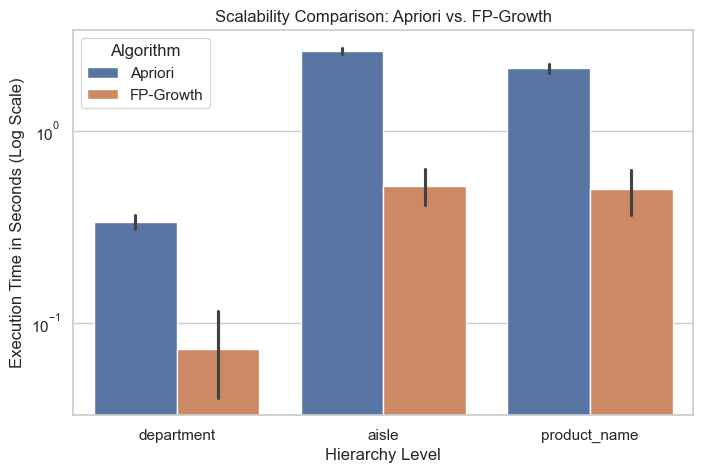

In [4]:
results = run_master_analysis(df_merged)

In [5]:
display(Markdown("### Misleading Rules (High Lift(>2) vs Low Kulczynski(<0.4))"))

conflicts_found = False
for (dim, level), df in results.items():
    if not df.empty:
        conflicting_rules = df[(df['lift'] > 2) & (df['kulczynski'] < 0.4)].copy()        
        if not conflicting_rules.empty:
            conflicts_found = True
            display(Markdown(f"**Dimension:** `{dim}` | **Level:** `{level}`"))
            conflicting_rules = conflicting_rules.sort_values('ir', ascending=False)
            cols_to_show = ['ant_str', 'cons_str', 'support', 'confidence', 'lift', 'kulczynski', 'ir']
            display(conflicting_rules[cols_to_show].head(5))

### Misleading Rules (High Lift(>2) vs Low Kulczynski(<0.4))

**Dimension:** `Weekend` | **Level:** `product_name`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
37257,"Hour_Morning, Lime Sparkling Water","Weekend, Sparkling Water Grapefruit",0.002922,0.500000,19.895349,0.30814,0.6875
37254,"Hour_Morning, Lime Sparkling Water, Weekend",Sparkling Water Grapefruit,0.002922,0.500000,19.895349,0.30814,0.6875
37265,Sparkling Water Grapefruit,"Hour_Morning, Lime Sparkling Water, Weekend",0.002922,0.116279,19.895349,0.30814,0.6875
37262,"Weekend, Sparkling Water Grapefruit","Hour_Morning, Lime Sparkling Water",0.002922,0.116279,19.895349,0.30814,0.6875
37247,Sparkling Water Grapefruit,"Hour_Morning, Lime Sparkling Water",0.002922,0.116279,19.895349,0.30814,0.6875


**Dimension:** `Weekday` | **Level:** `product_name`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
14017,"Weekday, Total 2% with Strawberry Lowfat Greek...",Total 2% Lowfat Greek Strained Yogurt With Blu...,0.002128,0.259259,65.592593,0.39886,0.424242
14021,Total 2% with Strawberry Lowfat Greek Strained...,Total 2% Lowfat Greek Strained Yogurt With Blu...,0.002128,0.259259,65.592593,0.39886,0.424242
14010,Total 2% Lowfat Greek Strained Yogurt With Blu...,Total 2% with Strawberry Lowfat Greek Strained...,0.002128,0.538462,65.592593,0.39886,0.424242
14014,Total 2% Lowfat Greek Strained Yogurt With Blu...,"Weekday, Total 2% with Strawberry Lowfat Greek...",0.002128,0.538462,65.592593,0.39886,0.424242
14009,Total 2% with Strawberry Lowfat Greek Strained...,Total 2% Lowfat Greek Strained Yogurt With Blu...,0.002128,0.259259,65.592593,0.39886,0.424242


...

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
30224,"Weekend, Lime Sparkling Water","Hour_Morning, Sparkling Water Grapefruit",0.003057,0.500000,19.017442,0.30814,0.6875
30229,Sparkling Water Grapefruit,"Hour_Morning, Weekend, Lime Sparkling Water",0.003057,0.116279,19.017442,0.30814,0.6875
30154,"Weekend, Lime Sparkling Water",Sparkling Water Grapefruit,0.003057,0.500000,19.017442,0.30814,0.6875
30159,Sparkling Water Grapefruit,"Weekend, Lime Sparkling Water",0.003057,0.116279,19.017442,0.30814,0.6875
30218,"Hour_Morning, Weekend, Lime Sparkling Water",Sparkling Water Grapefruit,0.003057,0.500000,19.017442,0.30814,0.6875


**Dimension:** `Hour_Afternoon` | **Level:** `product_name`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
23393,"Weekday, Large_Basket, Organic Strawberries, H...",Organic Yellow Peaches,0.002752,0.135417,26.654514,0.338542,0.672897
23402,"Weekday, Large_Basket, Organic Strawberries","Organic Yellow Peaches, Hour_Afternoon",0.002752,0.135417,26.654514,0.338542,0.672897
23379,"Weekday, Large_Basket, Organic Strawberries",Organic Yellow Peaches,0.002752,0.135417,26.654514,0.338542,0.672897
23386,Organic Yellow Peaches,"Weekday, Large_Basket, Organic Strawberries",0.002752,0.541667,26.654514,0.338542,0.672897
23405,"Organic Yellow Peaches, Hour_Afternoon","Weekday, Large_Basket, Organic Strawberries",0.002752,0.541667,26.654514,0.338542,0.672897


**Dimension:** `Hour_Evening` | **Level:** `product_name`

,ant_str,cons_str,support,confidence,lift,kulczynski,ir
758,"Cucumber Kirby, Large_Basket","Broccoli Crown, Banana",0.002216,0.133333,34.380952,0.352381,0.69697
763,"Broccoli Crown, Banana","Cucumber Kirby, Large_Basket",0.002216,0.571429,34.380952,0.352381,0.69697
776,"Cucumber Kirby, Large_Basket, Hour_Evening","Banana, Broccoli Crown",0.002216,0.133333,34.380952,0.352381,0.69697
780,"Banana, Hour_Evening, Broccoli Crown","Cucumber Kirby, Large_Basket",0.002216,0.571429,34.380952,0.352381,0.69697
783,"Cucumber Kirby, Large_Basket","Banana, Hour_Evening, Broccoli Crown",0.002216,0.133333,34.380952,0.352381,0.69697


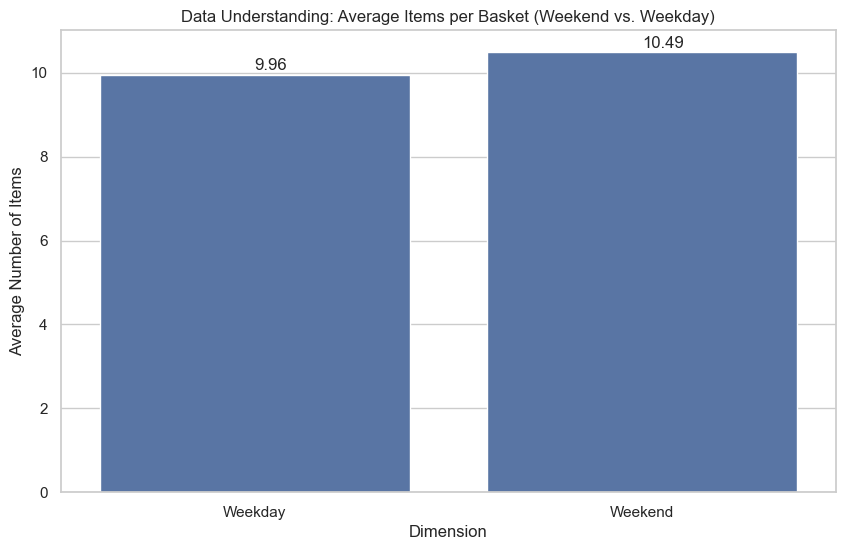

Weekend baskets are larger than Weekday baskets on average


##Multi-Level & Multi-Dimensional Mining Summary

,Dimension,Level,Total_Found,Robust_Count,Avg_Lift,Avg_Kulc
0,Weekend,Department,210,210,2.3706,0.5207
1,Weekend,Aisle,66,66,1.8399,0.5312
2,Weekend,Product_name,96,96,76.5342,0.4148
3,Weekday,Department,132,132,2.4093,0.5214
4,Weekday,Aisle,72,72,2.1024,0.5296
5,Weekday,Product_name,72,72,66.9436,0.4056


The 'Total_Found' column shows rules after hierarchical redundancy filtering

The 'Robust_Count' shows rules that passed the Kulczynski/IR thresholds

### Top 5 Robust Product Rules (Weekend vs. Weekday)

,Dimension,ant_str,cons_str,lift,kulczynski,cosine
0,Weekend,YoKids Squeeze Organic Blueberry Blue Yogurt,"Weekend, YoKids Squeeze! Organic Strawberry Fl...",272.205,0.756,0.746
1,Weekend,YoKids Squeeze Organic Blueberry Blue Yogurt,YoKids Squeeze! Organic Strawberry Flavor Yogurt,272.205,0.756,0.746
2,Weekend,"Weekend, YoKids Squeeze Organic Blueberry Blue...",YoKids Squeeze! Organic Strawberry Flavor Yogurt,272.205,0.756,0.746
3,Weekend,YoKids Squeeze! Organic Strawberry Flavor Yogurt,YoKids Squeeze Organic Blueberry Blue Yogurt,272.205,0.756,0.746
4,Weekend,"Weekend, YoKids Squeeze! Organic Strawberry Fl...",YoKids Squeeze Organic Blueberry Blue Yogurt,272.205,0.756,0.746
5,Weekday,"Weekday, Lemon Sparkling Water",Grapefruit Sparkling Water,98.389,0.464,0.458
6,Weekday,"Grapefruit Sparkling Water, Weekday",Lemon Sparkling Water,98.389,0.464,0.458
7,Weekday,Grapefruit Sparkling Water,"Weekday, Lemon Sparkling Water",98.389,0.464,0.458
8,Weekday,Lemon Sparkling Water,"Grapefruit Sparkling Water, Weekday",98.389,0.464,0.458
9,Weekday,Lemon Sparkling Water,Grapefruit Sparkling Water,98.389,0.464,0.458


### Robust Patterns: Morning vs. Night Shoppers

,Dimension,ant_str,cons_str,lift,kulczynski,cosine
0,Hour_Morning,Mixed Berries Whole Milk Icelandic Style Skyr ...,Vanilla Skyr Style Yogurt,208.155,0.668,0.667
1,Hour_Morning,"Hour_Morning, Vanilla Skyr Style Yogurt",Mixed Berries Whole Milk Icelandic Style Skyr ...,208.155,0.668,0.667
2,Hour_Morning,"Hour_Morning, Mixed Berries Whole Milk Iceland...",Vanilla Skyr Style Yogurt,208.155,0.668,0.667
3,Hour_Morning,Vanilla Skyr Style Yogurt,Mixed Berries Whole Milk Icelandic Style Skyr ...,208.155,0.668,0.667
4,Hour_Morning,Vanilla Skyr Style Yogurt,"Hour_Morning, Mixed Berries Whole Milk Iceland...",208.155,0.668,0.667


In [6]:
plt.figure(figsize=(10, 6))
basket_stats = df_merged.groupby(['day_type', 'order_id']).size().reset_index(name='items')
avg_items = basket_stats.groupby('day_type')['items'].mean()

sns.barplot(x=avg_items.index, y=avg_items.values)
plt.title('Data Understanding: Average Items per Basket (Weekend vs. Weekday)')
plt.ylabel('Average Number of Items')
plt.xlabel('Dimension')
for i, v in enumerate(avg_items.values): plt.text(i, v + 0.1, f"{v:.2f}")
plt.show()
print(f"{avg_items.idxmax()} baskets are larger than {avg_items.idxmin()} baskets on average")

summary_data = []

for dim in ['Weekend', 'Weekday']:
    for level in ['department', 'aisle', 'product_name']:
        key = (dim, level)
        if key in results:
            df = results[key]
            summary_data.append({
                'Dimension': dim,
                'Level': level.capitalize(),
                'Total_Found': len(df),
                'Robust_Count': df['is_robust'].sum(),
                'Avg_Lift': round(df['lift'].mean(), 4) if not df.empty else 0,
                'Avg_Kulc': round(df['kulczynski'].mean(), 4) if not df.empty else 0
            })

summary_df = pd.DataFrame(summary_data)
display(Markdown("##Multi-Level & Multi-Dimensional Mining Summary"))
display(summary_df)
display(Markdown("The 'Total_Found' column shows rules after hierarchical redundancy filtering"))
display(Markdown("The 'Robust_Count' shows rules that passed the Kulczynski/IR thresholds"))

weekend_top = get_top_robust('Weekend', 'product_name', results)
weekday_top = get_top_robust('Weekday', 'product_name', results)
comparison_table = pd.concat([weekend_top, weekday_top], ignore_index=True)

display(Markdown("### Top 5 Robust Product Rules (Weekend vs. Weekday)"))
display(comparison_table)

morning_top = get_top_robust('Hour_Morning', 'product_name', results)
night_top = get_top_robust('Hour_Night', 'product_name', results)

hourly_comparison = pd.concat([morning_top, night_top], ignore_index=True)

display(Markdown("### Robust Patterns: Morning vs. Night Shoppers"))
display(hourly_comparison)